In [1]:
%cd /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/
%ls

/workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection
dicom_metadata_15k.csv  sample_submission.csv  test/  train/  train.csv


In [2]:
import pydicom
import os

# Đường dẫn đến 1 file DICOM bất kỳ trong tập train
sample_dicom_path = "train/000434271f63a053c4128a0ba6352c7f.dicom" 

dicom_data = pydicom.dcmread(sample_dicom_path)

# In ra toàn bộ metadata để xem họ giữ lại những keys nào
print(dicom_data)

# Thử truy xuất trực tiếp demographic (nếu có)
try:
    print("Giới tính:", dicom_data.PatientSex)
    print("Tuổi:", dicom_data.PatientAge)
except AttributeError:
    print("Thông tin demographic đã bị xóa hoàn toàn.")

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 156
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Digital X-Ray Image Storage - For Presentation
(0002,0003) Media Storage SOP Instance UID      UI: 000434271f63a053c4128a0ba6352c7f
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.3.4
(0002,0013) Implementation Version Name         SH: ''
(0002,0016) Source Application Entity Title     AE: 'VITREA1'
-------------------------------------------------
(0010,0040) Patient's Sex                       CS: 'O'
(0028,0002) Samples per Pixel                   US: 1
(0028,0004) Photometric Interpretation          CS: 'MONOCHROME1'
(0028,0010) Rows                                US: 2836
(0028,0011) Columns                             US: 2336
(0028,0030) Pixel Spacing                       DS:

/usr/local/lib/python3.11/dist-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: '000434271f63a053c4128a0ba6352c7f'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


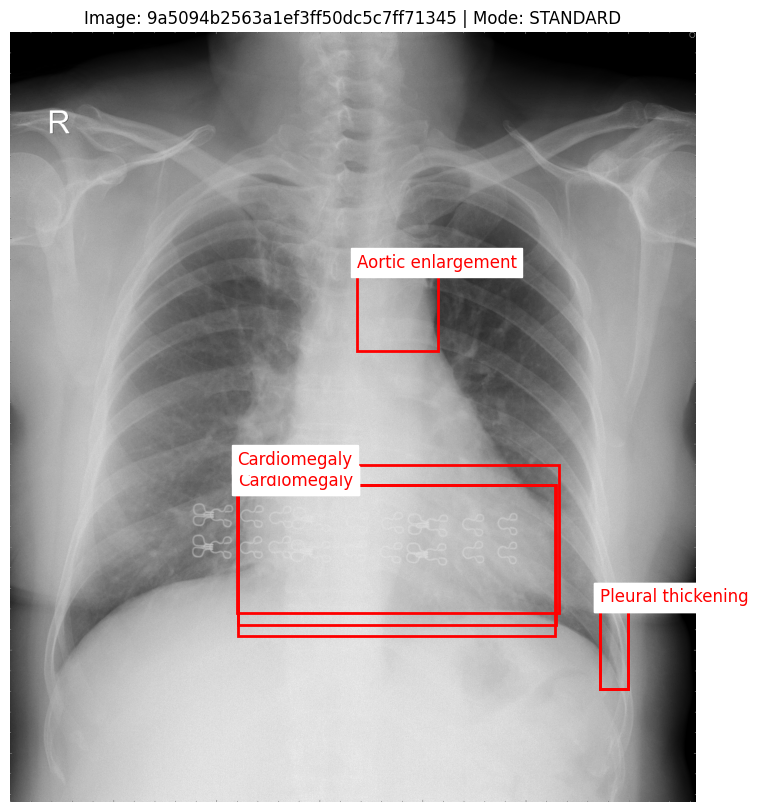

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

df = pd.read_csv('train.csv')

def plot_xray_with_boxes(image_id, df, view_mode="negative"):
    # Lấy thông tin boxes của ảnh
    img_data = df[df['image_id'] == image_id]
    
    # Đọc ảnh DICOM
    dicom_path = f"train/{image_id}.dicom"
    dcm = pydicom.dcmread(dicom_path)
    
    # DICOM thường cần apply LUT để hiển thị đúng độ tương phản
    img_array = apply_voi_lut(dcm.pixel_array, dcm) 
    
    # Xử lý đảo ngược (Inversion) dựa trên Photometric Interpretation
    is_monochrome1 = dcm.PhotometricInterpretation == "MONOCHROME1"
    
    if view_mode == "standard":
        # Chế độ chuẩn y khoa (Xương trắng, phổi đen)
        # Nếu gốc là MONOCHROME1 thì cần đảo ngược giá trị ma trận
        if is_monochrome1:
            img_array = np.amax(img_array) - img_array
    elif view_mode == "negative":
        # Chế độ âm bản (Xương đen, phổi trắng)
        # Nếu gốc KHÔNG PHẢI MONOCHROME1 thì mới đảo ngược
        if not is_monochrome1:
            img_array = np.amax(img_array) - img_array
            
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_array, cmap='gray')
    
    # Vẽ boxes
    for _, row in img_data.iterrows():
        if row['class_id'] != 14: # Bỏ qua 'No finding'
            xmin, ymin, xmax, ymax = row['x_min'], row['y_min'], row['x_max'], row['y_max']
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            ax.text(xmin, ymin, row['class_name'], color='red', fontsize=12, backgroundcolor='white')
            
    plt.title(f"Image: {image_id} | Mode: {view_mode.upper()}")
    plt.axis('off')
    plt.show()

# Test thử với 1 image_id có trong file csv
sample_id = df.loc[df['class_id'] != 14, 'image_id'].iloc[0]

# Chạy thử chế độ âm bản như bạn muốn
plot_xray_with_boxes(sample_id, df, view_mode="standard")

# Nếu sau này muốn xem chế độ chuẩn, bạn chỉ cần đổi:
# plot_xray_with_boxes(sample_id, df, view_mode="standard")

In [7]:
%pip install seaborn
%pip install ensemble-boxes
# %pip install albumentations


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Obtaining dependency information for ensemble-boxes from https://files.pythonhosted.org/packages/0e/5b/58e47cd45fc18da37205a80689606e0e203810f1beadbdaae620f491892b/ensemble_boxes-1.0.9-py3-none-any.whl.metadata
  Obtaining dependency information for numba from https://files.pythonhosted.org/packages/44/0b/0615dbedb98f5b32a35a53290fbdc6e22306968109278d7e58df82d7a9f6/numba-0.65.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Obtaining dependency information for llvmlite<0.48,>=0.47.0dev0 from https://files.pythonhosted.org/packages/46/27/5799b020e4cdfb25a7c951c06a96397c135efcdc21b78d853bbd9c814c7d/llvmlite-0.47.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 7.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━

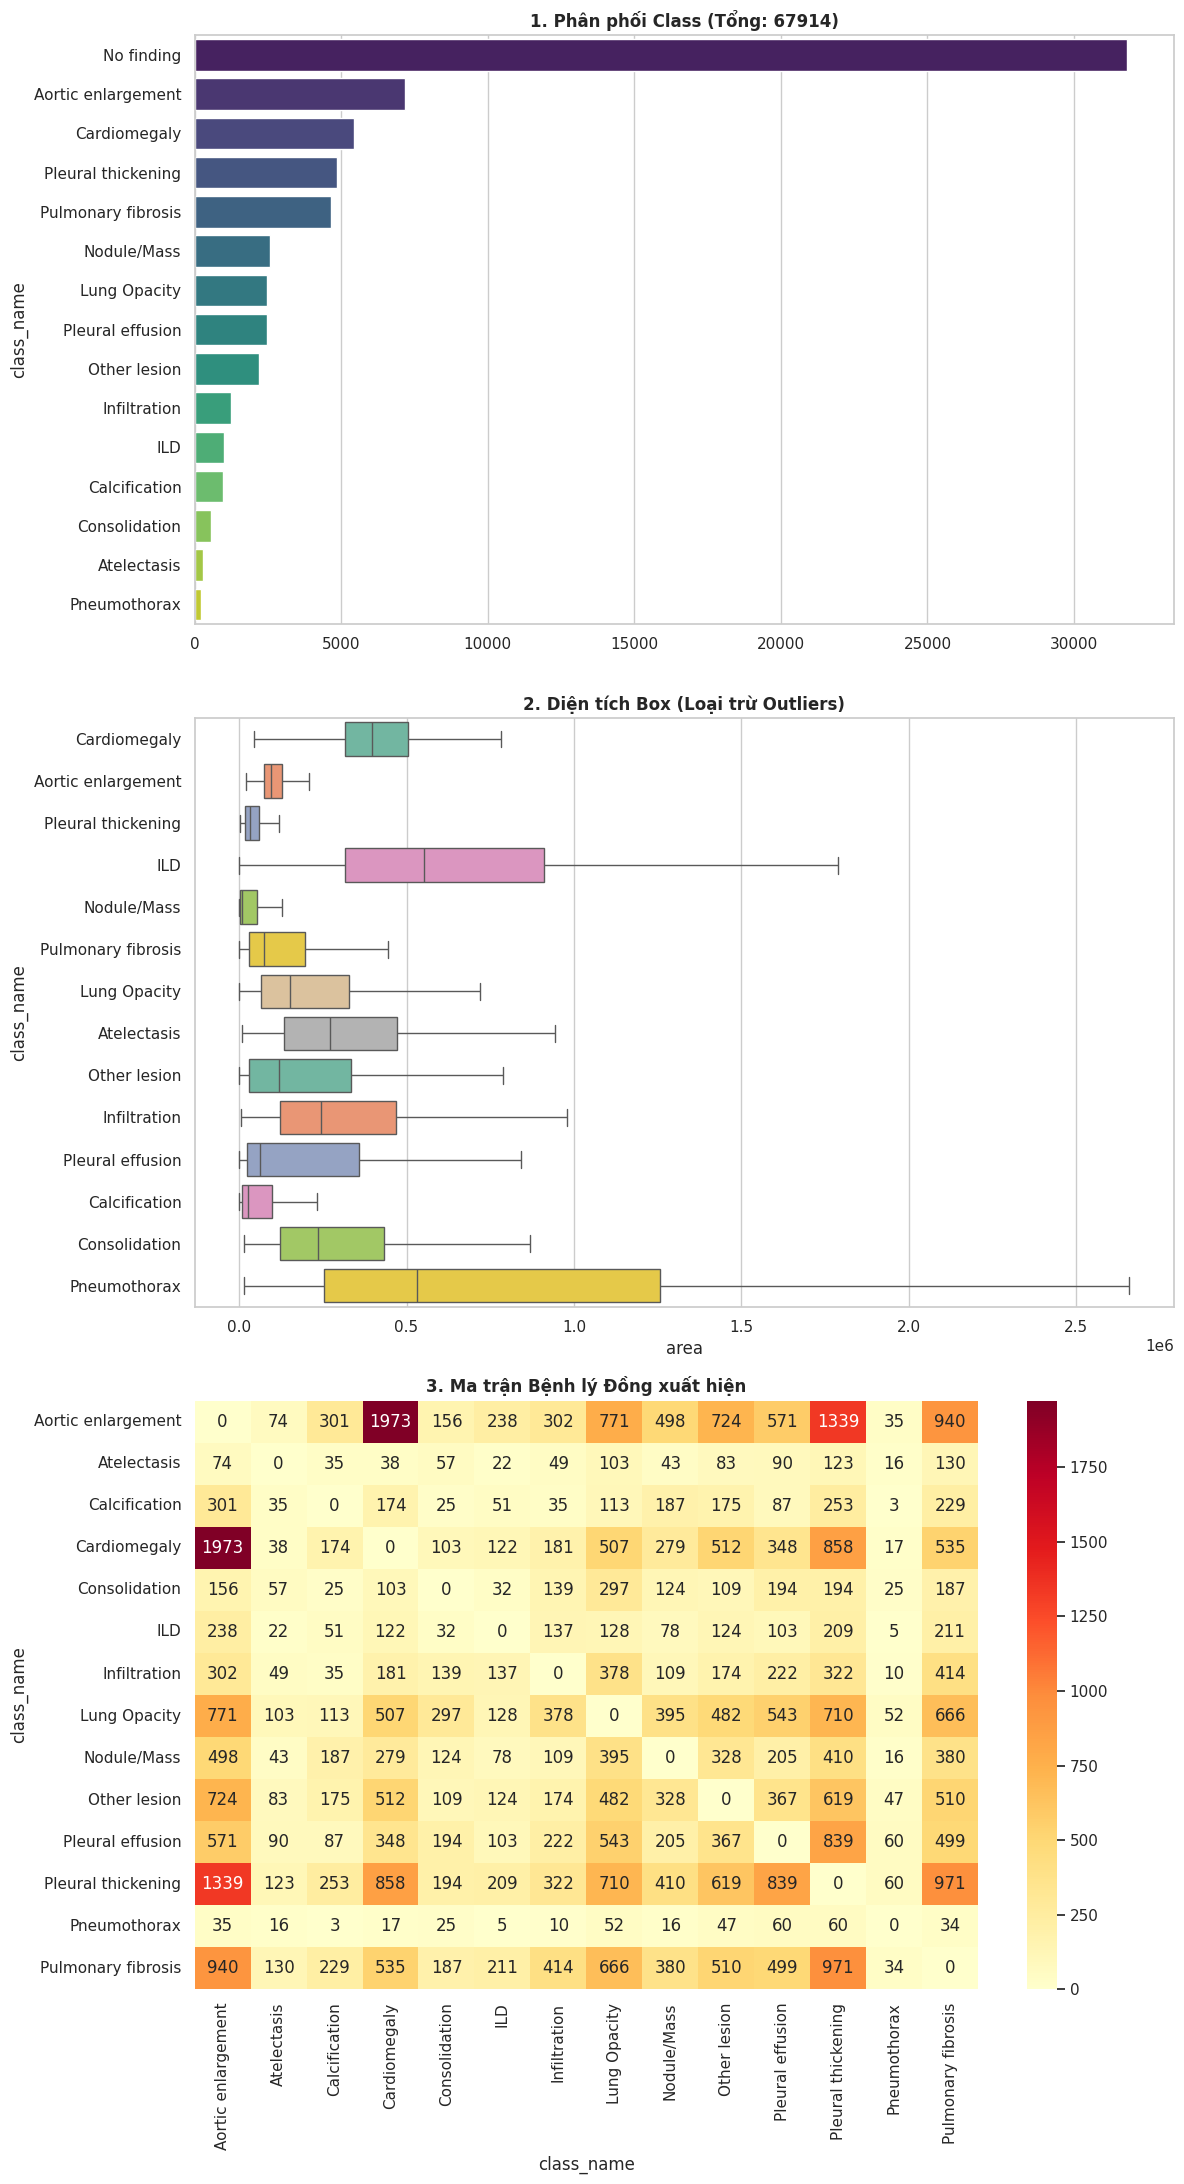

In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# 1. Đọc dữ liệu & Thiết lập nhanh
df = pd.read_csv('train.csv')
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 22))

# 2. Phân phối Class
cnt = df['class_name'].value_counts()
sns.barplot(x=cnt.values, y=cnt.index, hue=cnt.index, ax=axes[0], palette="viridis", legend=False)
axes[0].set_title(f"1. Phân phối Class (Tổng: {len(df)})", fontweight='bold')

# 3. Diện tích Bounding Box (Loại ID 14)
dfb = df[df.class_id != 14].copy()
dfb['area'] = (dfb.x_max - dfb.x_min) * (dfb.y_max - dfb.y_min)
sns.boxplot(data=dfb, x='area', y='class_name', hue='class_name', showfliers=False, ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("2. Diện tích Box (Loại trừ Outliers)", fontweight='bold')

# 4. Ma trận đồng xuất hiện (Fix lỗi Read-only bằng .mask)
# Gộp nhóm, tạo ma trận 0/1, nhân ma trận để tính co-occurrence
tmp = dfb.groupby(['image_id', 'class_name']).size().unstack(fill_value=0).gt(0).astype(int)
co = (tmp.T @ tmp).mask(np.eye(tmp.shape[1], dtype=bool), 0) # Gán đường chéo bằng 0 cực nhanh

sns.heatmap(co, annot=True, fmt="d", cmap="YlOrRd", ax=axes[2])
axes[2].set_title("3. Ma trận Bệnh lý Đồng xuất hiện", fontweight='bold')

plt.tight_layout(); 
plt.savefig('charts.png', dpi=300, bbox_inches='tight')
plt.show()

Processing: 100%|██████████| 15000/15000 [00:17<00:00, 833.83it/s]


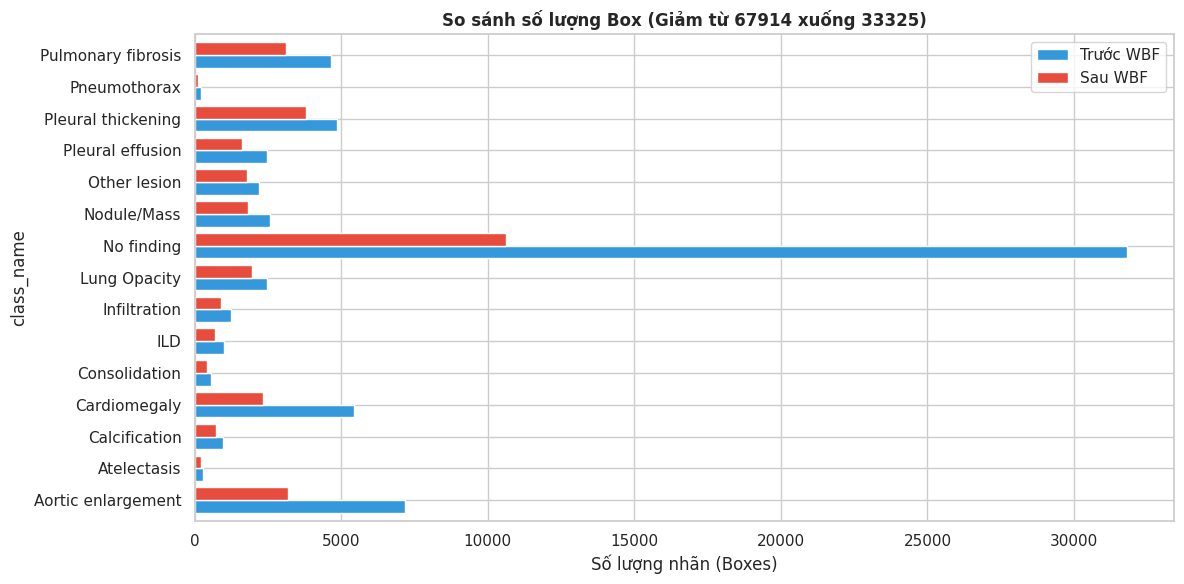

In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from ensemble_boxes import weighted_boxes_fusion
from tqdm import tqdm
# 1. Cấu hình & Tải dữ liệu
df = pd.read_csv('train.csv')
M, IOU, res = 10000.0, 0.4, []
cls_map = dict(zip(df.class_id, df.class_name))
# 2. Xử lý WBF ngắn gọn
for img_id, group in tqdm(df.groupby('image_id'), desc="Processing"):
    if group.class_id.max() == 14: # No finding
        res.append({'image_id': img_id, 'class_name': 'No finding', 'class_id': 14, 
                    'x_min': 0, 'y_min': 0, 'x_max': 1, 'y_max': 1})
        continue
    # Chuẩn bị dữ liệu cho WBF: Gộp theo bác sĩ (rad_id)
    gp = group[group.class_id != 14]
    b_list = [g[['x_min', 'y_min', 'x_max', 'y_max']].values / M for _, g in gp.groupby('rad_id')]
    s_list = [np.ones(len(b)) for b in b_list]
    l_list = [g.class_id.values for _, g in gp.groupby('rad_id')]
    boxes, scores, labels = weighted_boxes_fusion(b_list, s_list, l_list, iou_thr=IOU)
    for b, l in zip(boxes, labels):
        res.append({'image_id': img_id, 'class_id': int(l), 'class_name': cls_map[int(l)],
                    'x_min': b[0]*M, 'y_min': b[1]*M, 'x_max': b[2]*M, 'y_max': b[3]*M})
df_wbf = pd.DataFrame(res)
df_wbf.to_csv('train_wbf.csv', index=False)
# 3. Biểu đồ so sánh Trước & Sau
plt.figure(figsize=(12, 6))
compare_df = pd.DataFrame({
    'Trước WBF': df['class_name'].value_counts(),
    'Sau WBF': df_wbf['class_name'].value_counts()
}).fillna(0)
compare_df.plot(kind='barh', width=0.8, color=['#3498db', '#e74c3c'], ax=plt.gca())
plt.title(f"So sánh số lượng Box (Giảm từ {len(df)} xuống {len(df_wbf)})", fontweight='bold')
plt.xlabel("Số lượng nhãn (Boxes)"); plt.tight_layout(); plt.show()

In [9]:
print("Phân tích Dữ liệu Ảnh Raw")

Phân tích Dữ liệu Ảnh Raw


🚀 Bắt đầu xử lý toàn bộ 15000 ảnh...


Parsing DICOM Headers: 100%|██████████| 15000/15000 [03:51<00:00, 64.67it/s] 



✅ Đã quét xong! Đã lưu toàn bộ thông số vào file: dicom_metadata_15k.csv


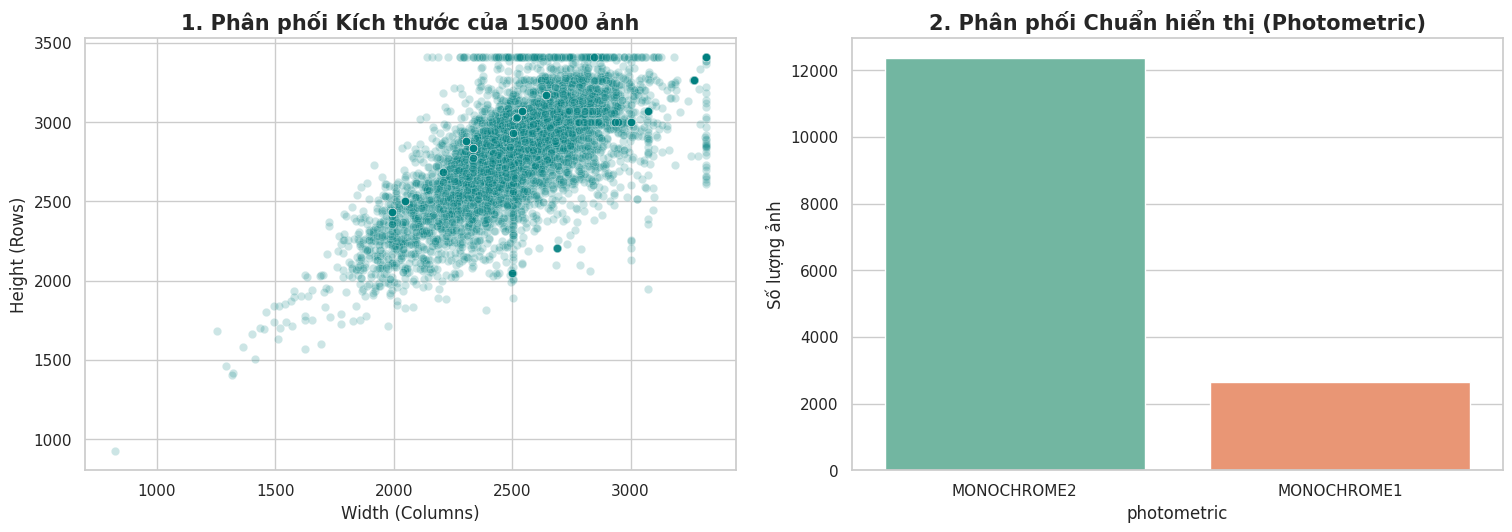


📊 BÁO CÁO INSIGHT CHO PIPELINE PYTORCH/TF:
🔸 Chiều rộng (Width) : Min=823, Max=3320, Trung bình=2446
🔸 Chiều cao (Height): Min=927, Max=3408, Trung bình=2787
🔸 Tỷ lệ khung hình   : Min=0.63, Max=1.58

🔴 LƯU Ý: Dữ liệu bị trộn lẫn nhiều chuẩn hiển thị!
photometric
MONOCHROME2    12357
MONOCHROME1     2643
Name: count, dtype: int64
=> Code Preprocessing: Bắt buộc phải check `if dcm.PhotometricInterpretation == 'MONOCHROME1':` trong hàm đọc ảnh.


In [10]:
import os
import pydicom
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

train_dir = 'train/'
# Lấy TẤT CẢ danh sách file dicom (Khoảng 15,000 ảnh)
all_files = [f for f in os.listdir(train_dir) if f.endswith('.dicom')]

print(f"🚀 Bắt đầu xử lý toàn bộ {len(all_files)} ảnh...")

# 1. TRÍCH XUẤT METADATA (TỐI ƯU HÓA BỘ NHỚ)
meta_data = []

# Quét qua 15,000 files
for f in tqdm(all_files, desc="Parsing DICOM Headers"):
    dcm_path = os.path.join(train_dir, f)
    
    # BẮT BUỘC: stop_before_pixels=True để không nổ RAM
    dcm = pydicom.dcmread(dcm_path, stop_before_pixels=True) 
    
    meta_data.append({
        'image_id': f.replace('.dicom', ''),
        'rows': int(dcm.Rows),
        'columns': int(dcm.Columns),
        'photometric': dcm.PhotometricInterpretation
    })

# 2. TẠO DATAFRAME VÀ LƯU BACKUP
df_meta = pd.DataFrame(meta_data)
df_meta['aspect_ratio'] = df_meta['columns'] / df_meta['rows']

# Lưu lại để lần sau chỉ cần pd.read_csv('dicom_metadata_15k.csv') là xong
df_meta.to_csv('dicom_metadata_15k.csv', index=False)
print("\n✅ Đã quét xong! Đã lưu toàn bộ thông số vào file: dicom_metadata_15k.csv")

# 3. TRỰC QUAN HÓA THỐNG KÊ 15K ẢNH
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.tight_layout(pad=4.0)

# 3.1. Scatter Plot: Phân phối Kích thước
# Dùng alpha=0.2 để thấy rõ vùng dữ liệu dày đặc (màu đậm) do có tới 15k điểm
sns.scatterplot(data=df_meta, x='columns', y='rows', alpha=0.2, color='teal', ax=axes[0])
axes[0].set_title(f"1. Phân phối Kích thước của {len(all_files)} ảnh", fontsize=15, fontweight='bold')
axes[0].set_xlabel("Width (Columns)")
axes[0].set_ylabel("Height (Rows)")

# 3.2. Bar Chart: Kênh màu
mono_counts = df_meta['photometric'].value_counts()
sns.barplot(x=mono_counts.index, y=mono_counts.values, hue=mono_counts.index, legend=False, palette="Set2", ax=axes[1])
axes[1].set_title("2. Phân phối Chuẩn hiển thị (Photometric)", fontsize=15, fontweight='bold')
axes[1].set_ylabel("Số lượng ảnh")

plt.show()

# 4. IN BÁO CÁO NHANH CHO PREPROCESSING
print("\n" + "="*50)
print("📊 BÁO CÁO INSIGHT CHO PIPELINE PYTORCH/TF:")
print("="*50)
print(f"🔸 Chiều rộng (Width) : Min={df_meta['columns'].min()}, Max={df_meta['columns'].max()}, Trung bình={df_meta['columns'].mean():.0f}")
print(f"🔸 Chiều cao (Height): Min={df_meta['rows'].min()}, Max={df_meta['rows'].max()}, Trung bình={df_meta['rows'].mean():.0f}")
print(f"🔸 Tỷ lệ khung hình   : Min={df_meta['aspect_ratio'].min():.2f}, Max={df_meta['aspect_ratio'].max():.2f}")

# Kiểm tra xem có bao nhiêu chuẩn màu
if len(mono_counts) == 1 and "MONOCHROME1" in mono_counts:
    print("\n🟢 TUYỆT VỜI: 100% ảnh là MONOCHROME1.")
    print("=> Code Preprocessing: Chỉ cần dùng đúng 1 công thức `np.amax(img) - img` cho mọi ảnh.")
else:
    print("\n🔴 LƯU Ý: Dữ liệu bị trộn lẫn nhiều chuẩn hiển thị!")
    print(mono_counts)
    print("=> Code Preprocessing: Bắt buộc phải check `if dcm.PhotometricInterpretation == 'MONOCHROME1':` trong hàm đọc ảnh.")

In [11]:
import torch, cv2, pydicom, numpy as np, albumentations as A
from torch.utils.data import Dataset
from pydicom.pixel_data_handlers.util import apply_voi_lut

class VinBigDataDataset(Dataset):
    def __init__(self, df, img_dir, target_size=512, transforms=None):
        self.df, self.img_dir, self.target_size = df, img_dir, target_size
        self.tf = transforms or A.Compose([
            A.LongestMaxSize(target_size),
            A.PadIfNeeded(target_size, target_size, border_mode=0, value=0)
        ])

    def __len__(self): return len(self.df)

    def _read_dicom(self, path):
        d = pydicom.dcmread(path)
        img = apply_voi_lut(d.pixel_array, d)
        if d.PhotometricInterpretation == "MONOCHROME1": img = img.max() - img
        # Chuẩn hóa nhanh về [0, 255]
        img = (img - img.min()) / (img.max() - img.min())
        return (img * 255).astype(np.uint8)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._read_dicom(f"{self.img_dir}/{row.image_id}.dicom")
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        
        # Augmentation & Chuyển đổi Tensor
        img = self.tf(image=img)['image']
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        
        return img_tensor, torch.tensor(row.class_id, dtype=torch.long)

Đã nạp Dataset: 36096 boxes
Tensor: torch.Size([3, 512, 512]) | torch.float32
🏷 Label ID: 3
 Pixel: 0.00 - 1.00


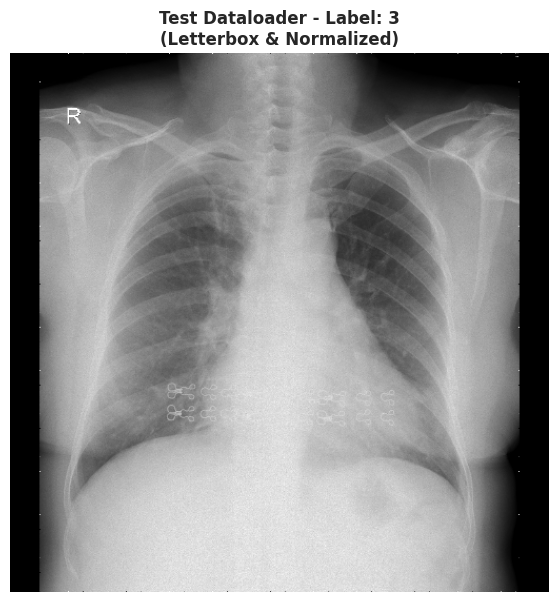

In [12]:
import matplotlib.pyplot as plt, pandas as pd

# 1. Nạp và lọc dữ liệu (Lấy ảnh có bệnh lý)
df = pd.read_csv('train.csv')
ds = VinBigDataDataset(df[df.class_id != 14].reset_index(), img_dir='train', target_size=512)

# 2. Lấy mẫu và in thông số (Debug nhanh)
img, lbl = ds[0]
print(f"Đã nạp Dataset: {len(ds)} boxes")
print(f"Tensor: {img.shape} | {img.dtype}\n🏷 Label ID: {lbl}\n Pixel: {img.min():.2f} - {img.max():.2f}")

# 3. Trực quan hóa
plt.figure(figsize=(7, 7))
plt.imshow(img.permute(1, 2, 0)) # Chuyển C,H,W -> H,W,C để hiển thị
plt.title(f"Test Dataloader - Label: {lbl.item()}\n(Letterbox & Normalized)", fontweight='bold')
plt.axis('off'); plt.show()

TRACK B EDA 1 FIX — CONTINUE WITHOUT agreement_score
⚠️ train_wbf.csv không có agreement_score → bỏ qua agreement-aware analysis.


,image_id,class_name,bbox_w,bbox_h,relative_area,bbox_aspect_ratio,size_group
0,0005e8e3701dfb1dd93d53e2ff537b6e,Lung Opacity,301.500037,304.000005,0.009712,0.991776,small <1%
1,0005e8e3701dfb1dd93d53e2ff537b6e,Consolidation,265.000000,329.000000,0.009238,0.805471,small <1%
2,0005e8e3701dfb1dd93d53e2ff537b6e,Nodule/Mass,265.000000,329.000000,0.009238,0.805471,small <1%
3,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,305.000000,301.000000,0.009728,1.013289,small <1%
4,0007d316f756b3fa0baea2ff514ce945,Aortic enlargement,235.000104,231.000036,0.008181,1.017316,small <1%



Class-level summary:


,n_boxes,median_rel_area,mean_rel_area,median_aspect,small_ratio,too_small_16_512,too_small_16_768,too_small_16_1024,too_small_16_1280
class_name,,,,,,,,,
Nodule/Mass,1821,0.0011,0.0093,0.9855,0.8166,0.5409,0.3317,0.1834,0.1054
Calcification,724,0.0033,0.0116,0.8562,0.7182,0.3453,0.1644,0.0635,0.0221
Pleural thickening,3796,0.0042,0.0081,1.5478,0.8201,0.2858,0.0917,0.0274,0.0097
Pleural effusion,1606,0.0064,0.0279,0.7117,0.6115,0.1133,0.0181,0.0025,0.0012
Pulmonary fibrosis,3131,0.0086,0.0183,0.9934,0.5372,0.1658,0.0690,0.0271,0.0112
Aortic enlargement,3201,0.0134,0.0165,0.9041,0.1953,0.0000,0.0000,0.0000,0.0000
Other lesion,1779,0.0148,0.0336,0.8194,0.4177,0.1720,0.0950,0.0467,0.0219
Lung Opacity,1942,0.0190,0.0316,0.8869,0.2935,0.0515,0.0175,0.0031,0.0015
Consolidation,428,0.0290,0.0420,0.8903,0.1308,0.0000,0.0000,0.0000,0.0000


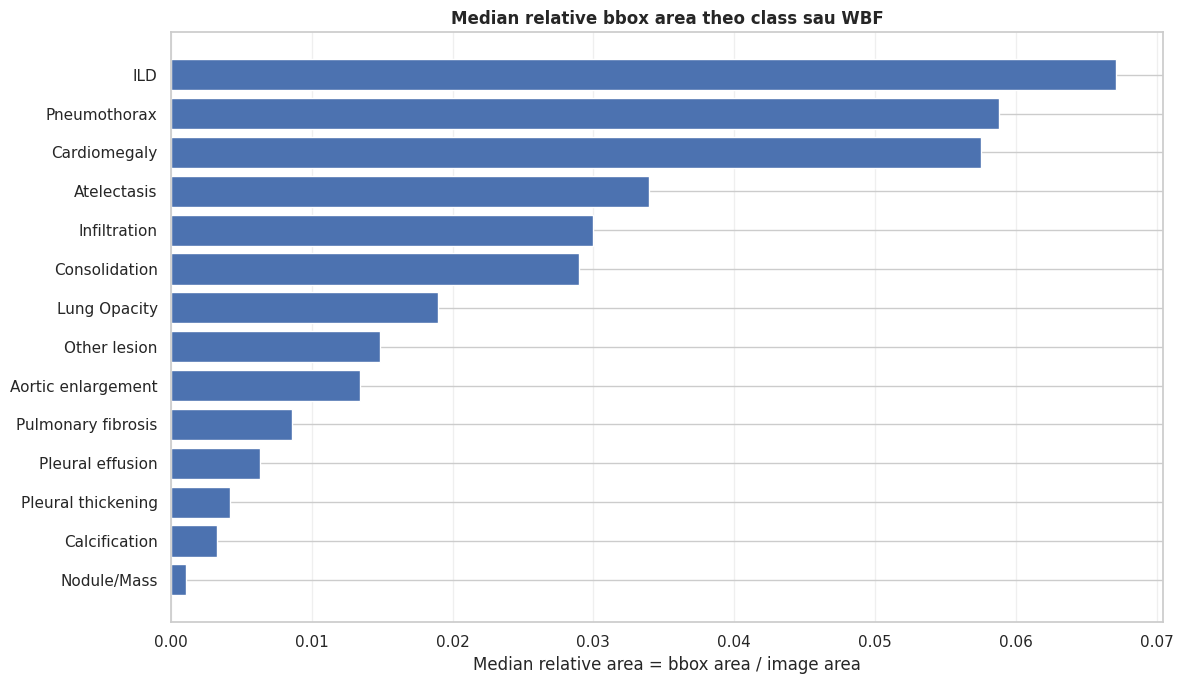

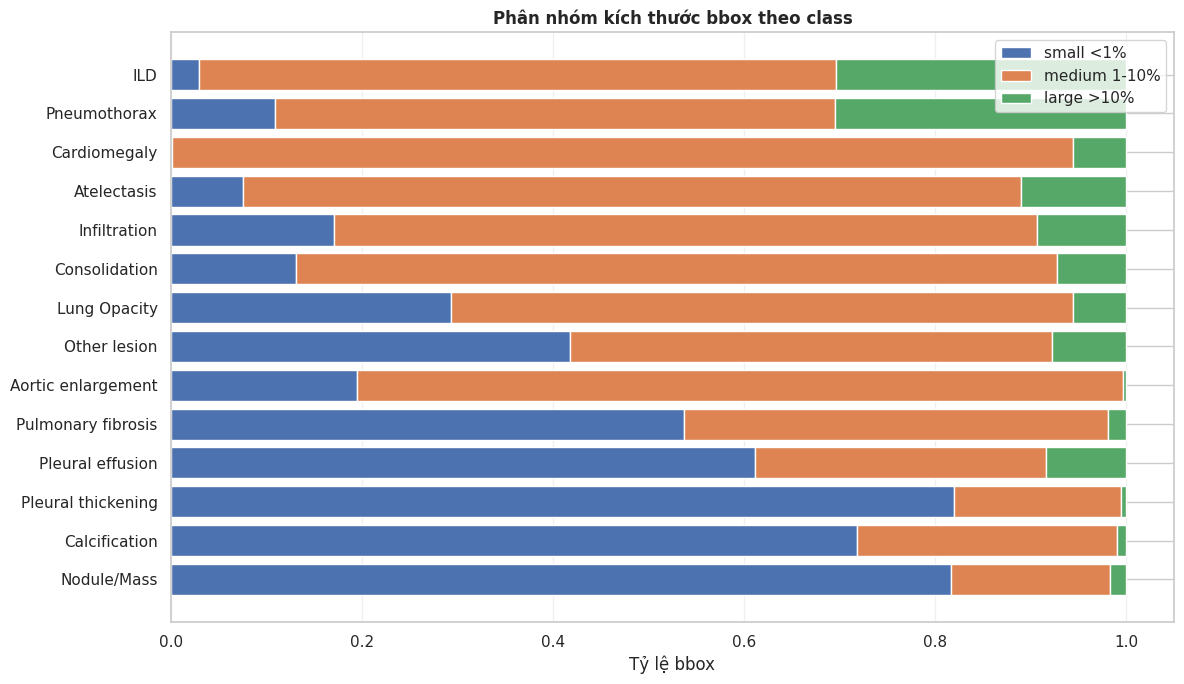

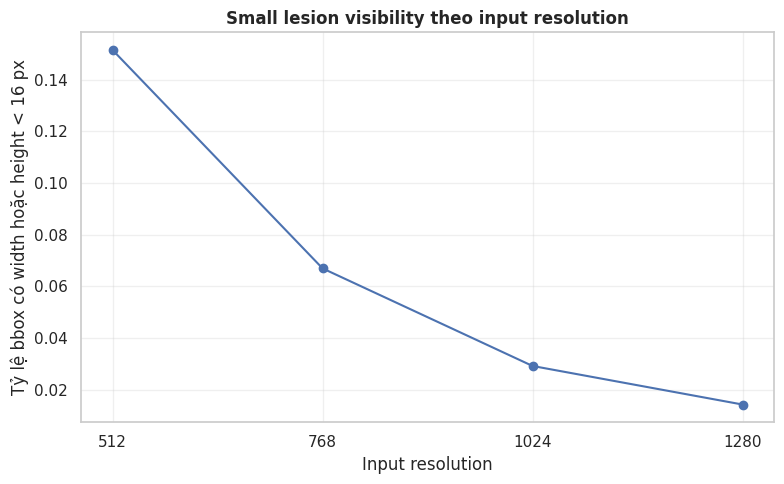

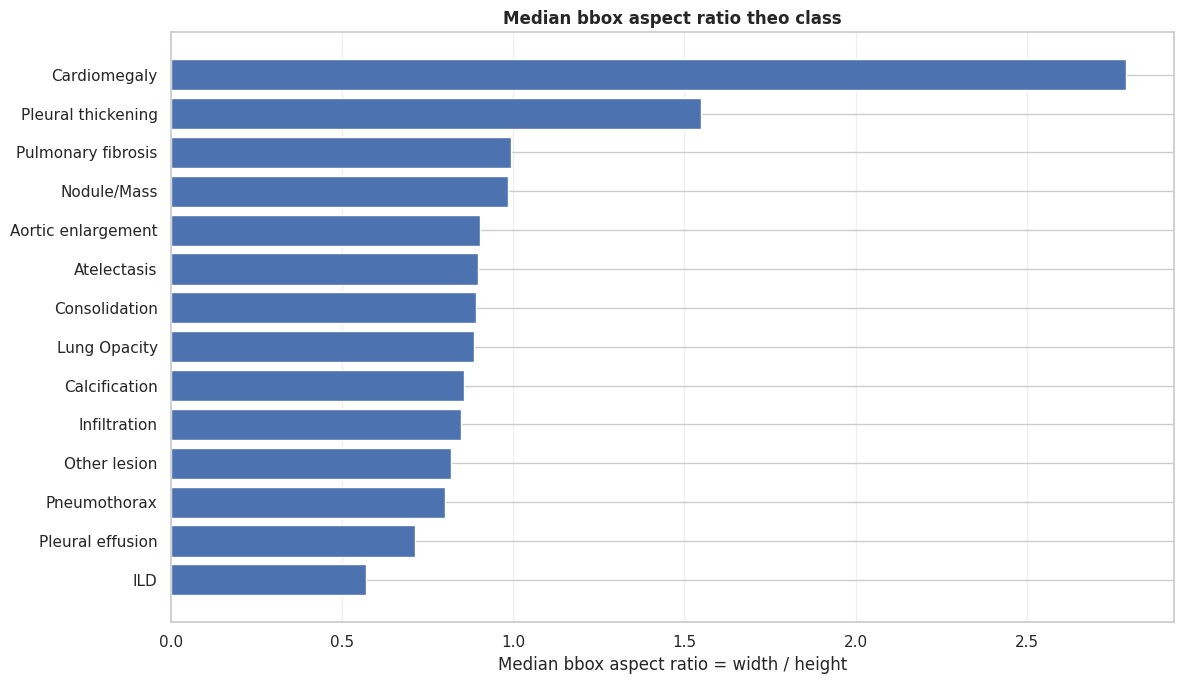


⚠️ Không vẽ agreement plot vì train_wbf.csv hiện tại không có agreement_score.

TRACK B EDA 1 SUMMARY
Total WBF boxes                  : 22,719
Overall small box ratio <1% area : 0.440
Too-small ratio at 512, <16 px   : 0.152
Too-small ratio at 768, <16 px   : 0.067
Too-small ratio at 1024, <16 px  : 0.029
Too-small ratio at 1280, <16 px  : 0.014
Saved bbox EDA CSV               : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_eda/bbox_eda_after_wbf.csv
Saved class summary CSV          : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_eda/class_bbox_summary_after_wbf.csv
Mean agreement score             : unavailable in current train_wbf.csv

Design implications for Track B:
- Small box ratio cao → cần P2 feature level + high-resolution training.
- Nhiều bbox quá nhỏ ở 512 → ưu tiên 1024 hoặc 1280.
- Aspect ratio biến thiên mạnh → ưu tiên anchor-free / transformer-bas

In [16]:
# ============================================================
# TRACK B - EDA 1 FIX: CONTINUE AFTER MISSING agreement_score
# ============================================================

print("=" * 80)
print("TRACK B EDA 1 FIX — CONTINUE WITHOUT agreement_score")
print("=" * 80)

# ------------------------------------------------------------
# 1. Fix missing columns
# ------------------------------------------------------------

if "agreement_score" not in bbox_df.columns:
    bbox_df["agreement_score"] = np.nan
    print("⚠️ train_wbf.csv không có agreement_score → bỏ qua agreement-aware analysis.")

if "class_name" not in bbox_df.columns:
    bbox_df["class_name"] = bbox_df["class_id"].map(CLASS_ID_TO_NAME)

display_cols = [
    "image_id", "class_name", "bbox_w", "bbox_h",
    "relative_area", "bbox_aspect_ratio", "size_group"
]

if bbox_df["agreement_score"].notna().any():
    display_cols.insert(-1, "agreement_score")

display(bbox_df[display_cols].head())

# ------------------------------------------------------------
# 2. Class-level summary
# ------------------------------------------------------------

agg_dict = dict(
    n_boxes=("image_id", "count"),
    median_rel_area=("relative_area", "median"),
    mean_rel_area=("relative_area", "mean"),
    median_aspect=("bbox_aspect_ratio", "median"),
    small_ratio=("size_group", lambda x: (x == "small <1%").mean()),
    too_small_16_512=("too_small_16_at_512", "mean"),
    too_small_16_768=("too_small_16_at_768", "mean"),
    too_small_16_1024=("too_small_16_at_1024", "mean"),
    too_small_16_1280=("too_small_16_at_1280", "mean"),
)

if bbox_df["agreement_score"].notna().any():
    agg_dict["mean_agreement"] = ("agreement_score", "mean")

class_summary = (
    bbox_df
    .groupby("class_name")
    .agg(**agg_dict)
    .sort_values("median_rel_area")
)

summary_csv = TRACKB_EDA_DIR / "class_bbox_summary_after_wbf.csv"
class_summary.to_csv(summary_csv)

print("\nClass-level summary:")
display(class_summary.round(4))

# ------------------------------------------------------------
# 3. Plot 1 — Relative bbox area
# ------------------------------------------------------------

plot_df = class_summary.sort_values("median_rel_area")

plt.figure(figsize=(12, 7))
plt.barh(plot_df.index, plot_df["median_rel_area"])
plt.xlabel("Median relative area = bbox area / image area")
plt.title("Median relative bbox area theo class sau WBF", fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Plot 2 — Small / medium / large distribution
# ------------------------------------------------------------

size_dist = (
    bbox_df
    .groupby(["class_name", "size_group"])
    .size()
    .unstack(fill_value=0)
)

size_dist_ratio = size_dist.div(size_dist.sum(axis=1), axis=0)
size_dist_ratio = size_dist_ratio.loc[class_summary.index]

plt.figure(figsize=(12, 7))
left = np.zeros(len(size_dist_ratio))

for col in size_dist_ratio.columns:
    vals = size_dist_ratio[col].values
    plt.barh(size_dist_ratio.index, vals, left=left, label=str(col))
    left += vals

plt.xlabel("Tỷ lệ bbox")
plt.title("Phân nhóm kích thước bbox theo class", fontweight="bold")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Plot 3 — Too-small ratio by resolution
# ------------------------------------------------------------

small_res_df = pd.DataFrame({
    "512": bbox_df["too_small_16_at_512"].mean(),
    "768": bbox_df["too_small_16_at_768"].mean(),
    "1024": bbox_df["too_small_16_at_1024"].mean(),
    "1280": bbox_df["too_small_16_at_1280"].mean(),
}, index=["too_small_ratio"]).T

plt.figure(figsize=(8, 5))
plt.plot(small_res_df.index, small_res_df["too_small_ratio"], marker="o")
plt.ylabel("Tỷ lệ bbox có width hoặc height < 16 px")
plt.xlabel("Input resolution")
plt.title("Small lesion visibility theo input resolution", fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Plot 4 — Aspect ratio by class
# ------------------------------------------------------------

aspect_df = class_summary.sort_values("median_aspect")

plt.figure(figsize=(12, 7))
plt.barh(aspect_df.index, aspect_df["median_aspect"])
plt.xlabel("Median bbox aspect ratio = width / height")
plt.title("Median bbox aspect ratio theo class", fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Optional agreement plot
# ------------------------------------------------------------

if "mean_agreement" in class_summary.columns:
    agreement_df = class_summary.sort_values("mean_agreement")

    plt.figure(figsize=(12, 7))
    plt.barh(agreement_df.index, agreement_df["mean_agreement"])
    plt.xlabel("Mean agreement score")
    plt.title("Mức độ đồng thuận annotation theo class sau WBF", fontweight="bold")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Không vẽ agreement plot vì train_wbf.csv hiện tại không có agreement_score.")

# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------

small_ratio_all = (bbox_df["size_group"] == "small <1%").mean()
too_small_512 = bbox_df["too_small_16_at_512"].mean()
too_small_768 = bbox_df["too_small_16_at_768"].mean()
too_small_1024 = bbox_df["too_small_16_at_1024"].mean()
too_small_1280 = bbox_df["too_small_16_at_1280"].mean()

print("\n" + "=" * 80)
print("TRACK B EDA 1 SUMMARY")
print("=" * 80)
print(f"Total WBF boxes                  : {len(bbox_df):,}")
print(f"Overall small box ratio <1% area : {small_ratio_all:.3f}")
print(f"Too-small ratio at 512, <16 px   : {too_small_512:.3f}")
print(f"Too-small ratio at 768, <16 px   : {too_small_768:.3f}")
print(f"Too-small ratio at 1024, <16 px  : {too_small_1024:.3f}")
print(f"Too-small ratio at 1280, <16 px  : {too_small_1280:.3f}")
print(f"Saved bbox EDA CSV               : {bbox_eda_csv}")
print(f"Saved class summary CSV          : {summary_csv}")

if "mean_agreement" in class_summary.columns:
    print(f"Mean agreement score             : {bbox_df['agreement_score'].mean():.3f}")
else:
    print("Mean agreement score             : unavailable in current train_wbf.csv")

print("\nDesign implications for Track B:")
print("- Small box ratio cao → cần P2 feature level + high-resolution training.")
print("- Nhiều bbox quá nhỏ ở 512 → ưu tiên 1024 hoặc 1280.")
print("- Aspect ratio biến thiên mạnh → ưu tiên anchor-free / transformer-based detector.")
print("- Agreement-aware loss cần train_wbf có thêm rad_count/agreement_score.")

In [17]:
# ============================================================
# TRACK B - CELL 1: MODEL DESIGN CONFIG
# CXR-DINO / Co-DETR style detector for VinDr-CXR
# ============================================================

print("=" * 80)
print("TRACK B CELL 1 — MODEL DESIGN CONFIG")
print("=" * 80)

from pathlib import Path
import json
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Local project paths
# ------------------------------------------------------------

DATA_DIR = Path(".").resolve()

TRAIN_CSV = DATA_DIR / "train.csv"
WBF_CSV = DATA_DIR / "train_wbf.csv"
META_CSV = DATA_DIR / "dicom_metadata_15k.csv"

TRACKB_DIR = DATA_DIR / "trackB_cxr_dino"
TRACKB_DATA_DIR = TRACKB_DIR / "data"
TRACKB_CONFIG_DIR = TRACKB_DIR / "configs"
TRACKB_WORK_DIR = TRACKB_DIR / "work_dirs"
TRACKB_EDA_DIR = DATA_DIR / "trackB_eda"

for p in [TRACKB_DIR, TRACKB_DATA_DIR, TRACKB_CONFIG_DIR, TRACKB_WORK_DIR]:
    p.mkdir(parents=True, exist_ok=True)

assert TRAIN_CSV.exists(), f"Missing: {TRAIN_CSV}"
assert WBF_CSV.exists(), f"Missing: {WBF_CSV}"
assert META_CSV.exists(), f"Missing: {META_CSV}"

print(f"DATA_DIR          : {DATA_DIR}")
print(f"TRACKB_DIR        : {TRACKB_DIR}")
print(f"TRACKB_DATA_DIR   : {TRACKB_DATA_DIR}")
print(f"TRACKB_CONFIG_DIR : {TRACKB_CONFIG_DIR}")
print(f"TRACKB_WORK_DIR   : {TRACKB_WORK_DIR}")

# ------------------------------------------------------------
# 2. Dataset constants
# ------------------------------------------------------------

NO_FINDING_CLASS_ID = 14

CLASS_NAMES = [
    "Aortic enlargement",
    "Atelectasis",
    "Calcification",
    "Cardiomegaly",
    "Consolidation",
    "ILD",
    "Infiltration",
    "Lung Opacity",
    "Nodule/Mass",
    "Other lesion",
    "Pleural effusion",
    "Pleural thickening",
    "Pneumothorax",
    "Pulmonary fibrosis",
]

NUM_CLASSES = len(CLASS_NAMES)

CLASS_ID_TO_NAME = {i: name for i, name in enumerate(CLASS_NAMES)}
CLASS_NAME_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

print("\nDetection classes:")
for i, name in CLASS_ID_TO_NAME.items():
    print(f"{i:2d}: {name}")

# ------------------------------------------------------------
# 3. Track B architecture decision from EDA
# ------------------------------------------------------------

TRACKB_MODEL_DESIGN = {
    "model_family": "DINO / Co-DETR style detector",
    "task": "Chest X-ray abnormality detection",
    "num_classes": NUM_CLASSES,

    # EDA-driven decisions
    "eda_findings": {
        "small_box_ratio_lt_1pct": 0.440,
        "too_small_ratio_512_lt_16px": 0.152,
        "too_small_ratio_768_lt_16px": 0.067,
        "too_small_ratio_1024_lt_16px": 0.029,
        "too_small_ratio_1280_lt_16px": 0.014,
    },

    # Design choices
    "input_resolution": {
        "debug": 768,
        "main_train": 1024,
        "finetune": 1280,
    },

    "backbone_options": [
        "Swin-L",
        "ConvNeXtV2-L",
        "ResNet50 baseline if memory/debug issue"
    ],

    "neck": {
        "type": "FPN / ChannelMapper",
        "feature_levels": ["P2", "P3", "P4", "P5"],
        "reason": "44% bbox are small objects; P2 preserves high-resolution features."
    },

    "detector_head": {
        "type": "DINO / Deformable DETR query-based head",
        "num_queries": 300,
        "reason": "Anchor-free/query-based detector handles diverse bbox shapes."
    },

    "training_strategy": {
        "mixed_precision": True,
        "input_size_main": 1024,
        "input_size_finetune": 1280,
        "batch_size_start": 2,
        "gradient_accumulation": True,
        "augmentations": [
            "random_resize",
            "horizontal_flip",
            "mild brightness/contrast",
            "avoid vertical flip",
            "avoid strong rotation"
        ]
    },

    "future_extension": {
        "agreement_aware_loss": "requires regenerated WBF with agreement_score",
        "auxiliary_classifier_branch": "multi-label ASL branch for re-scoring",
        "auxiliary_dense_head": "Co-DETR style training supervision for small lesions"
    }
}

design_json = TRACKB_CONFIG_DIR / "trackB_model_design.json"
with open(design_json, "w") as f:
    json.dump(TRACKB_MODEL_DESIGN, f, indent=2)

print(f"\nSaved model design JSON: {design_json}")

# ------------------------------------------------------------
# 4. Practical implementation choice
# ------------------------------------------------------------

print("\nImplementation plan:")
print("1. Convert WBF annotations to COCO detection format.")
print("2. Use MMDetection DINO / Co-DETR style config.")
print("3. Train main experiment at 1024 resolution.")
print("4. Fine-tune at 1280 if GPU memory allows.")
print("5. Compare Track B mAP with Track A YOLO.")
print("6. Optional: regenerate WBF with agreement_score for agreement-aware loss.")

# ------------------------------------------------------------
# 5. Recommended starting experiment
# ------------------------------------------------------------

TRACKB_EXPERIMENT = {
    "experiment_name": "cxr_dino_swinl_1024_fold0",
    "framework": "MMDetection",
    "detector": "DINO / Deformable DETR",
    "backbone": "Swin-L or ConvNeXtV2-L",
    "img_size": 1024,
    "num_classes": NUM_CLASSES,
    "num_queries": 300,
    "train_val_split": "5-fold multilabel stratified or fixed fold0",
    "annotation_source": "train_wbf.csv",
    "metric": "mAP@IoU=0.4 plus COCO mAP",
}

experiment_json = TRACKB_CONFIG_DIR / "trackB_starting_experiment.json"
with open(experiment_json, "w") as f:
    json.dump(TRACKB_EXPERIMENT, f, indent=2)

print(f"Saved experiment JSON: {experiment_json}")

print("\n" + "=" * 80)
print("TRACK B CELL 1 SUMMARY")
print("=" * 80)
print("Chosen direction : CXR-DINO / Co-DETR style detector")
print("Main resolution  : 1024")
print("Fine-tune option : 1280")
print("Feature design   : include P2/P3/P4/P5 for small lesions")
print("Detector style   : anchor-free / query-based")
print("Next cell        : Convert WBF annotations to COCO format")

TRACK B CELL 1 — MODEL DESIGN CONFIG
DATA_DIR          : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection
TRACKB_DIR        : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino
TRACKB_DATA_DIR   : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data
TRACKB_CONFIG_DIR : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/configs
TRACKB_WORK_DIR   : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/work_dirs

Detection classes:
 0: Aortic enlargement
 1: Atelectasis
 2: Calcification
 3: Cardiomegaly
 4: Consolidation
 5: ILD
 6: Infiltration
 7: Lung Opacity
 8: Nodule/Mass
 9: Other lesion
10: Pleural effusion
11: Pleural thickening
12: Pneumothorax
13: Pulmonary fibrosis

Save

In [18]:
# ============================================================
# TRACK B - CELL 2: TRAIN/VAL SPLIT + CONVERT WBF TO COCO FORMAT
# For CXR-DINO / Co-DETR style detector
# ============================================================

print("=" * 80)
print("TRACK B CELL 2 — WBF TO COCO FORMAT")
print("=" * 80)

from pathlib import Path
import json
import sys
import subprocess
import importlib.util

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedKFold

# ------------------------------------------------------------
# 1. Local paths
# ------------------------------------------------------------

DATA_DIR = Path(".").resolve()

TRAIN_CSV = DATA_DIR / "train.csv"
WBF_CSV = DATA_DIR / "train_wbf.csv"
META_CSV = DATA_DIR / "dicom_metadata_15k.csv"

TRACKB_DIR = DATA_DIR / "trackB_cxr_dino"
TRACKB_DATA_DIR = TRACKB_DIR / "data"
TRACKB_ANN_DIR = TRACKB_DATA_DIR / "annotations"
TRACKB_SPLIT_DIR = TRACKB_DATA_DIR / "splits"

for p in [TRACKB_DIR, TRACKB_DATA_DIR, TRACKB_ANN_DIR, TRACKB_SPLIT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR        : {DATA_DIR}")
print(f"TRACKB_DIR      : {TRACKB_DIR}")
print(f"TRACKB_ANN_DIR  : {TRACKB_ANN_DIR}")
print(f"TRACKB_SPLIT_DIR: {TRACKB_SPLIT_DIR}")

assert TRAIN_CSV.exists(), f"Missing train.csv: {TRAIN_CSV}"
assert WBF_CSV.exists(), f"Missing train_wbf.csv: {WBF_CSV}"
assert META_CSV.exists(), f"Missing metadata: {META_CSV}"


# ------------------------------------------------------------
# 2. Constants
# ------------------------------------------------------------

SEED = 42
N_FOLDS = 5
FOLD = 0

NO_FINDING_CLASS_ID = 14

CLASS_NAMES = [
    "Aortic enlargement",
    "Atelectasis",
    "Calcification",
    "Cardiomegaly",
    "Consolidation",
    "ILD",
    "Infiltration",
    "Lung Opacity",
    "Nodule/Mass",
    "Other lesion",
    "Pleural effusion",
    "Pleural thickening",
    "Pneumothorax",
    "Pulmonary fibrosis",
]

NUM_CLASSES = len(CLASS_NAMES)
CLASS_ID_TO_NAME = {i: name for i, name in enumerate(CLASS_NAMES)}

# COCO category_id thường bắt đầu từ 1.
# VinDr class_id 0–13 sẽ map sang COCO category_id 1–14.
CLASS_ID_TO_COCO_ID = {i: i + 1 for i in range(NUM_CLASSES)}
COCO_ID_TO_CLASS_ID = {i + 1: i for i in range(NUM_CLASSES)}

print("\nClasses:")
for i, name in CLASS_ID_TO_NAME.items():
    print(f"{i:2d} -> COCO {CLASS_ID_TO_COCO_ID[i]:2d}: {name}")


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(TRAIN_CSV)
df_wbf = pd.read_csv(WBF_CSV)
df_meta = pd.read_csv(META_CSV)

# Normalize metadata column names
if "width" not in df_meta.columns and "columns" in df_meta.columns:
    df_meta["width"] = df_meta["columns"]

if "height" not in df_meta.columns and "rows" in df_meta.columns:
    df_meta["height"] = df_meta["rows"]

df_meta["width"] = pd.to_numeric(df_meta["width"], errors="coerce").astype(int)
df_meta["height"] = pd.to_numeric(df_meta["height"], errors="coerce").astype(int)

print("\nLoaded:")
print(f"train.csv     : {df.shape}")
print(f"train_wbf.csv : {df_wbf.shape}")
print(f"metadata      : {df_meta.shape}")

assert df_meta["image_id"].nunique() == 15000, "Metadata image count should be 15,000."


# ------------------------------------------------------------
# 4. Build image-level multilabel table
# ------------------------------------------------------------

def build_image_level_table(df_wbf, df_meta):
    all_image_ids = sorted(df_meta["image_id"].unique())

    abn = df_wbf[df_wbf["class_id"] != NO_FINDING_CLASS_ID].copy()
    abn["class_id"] = abn["class_id"].astype(int)

    image_to_classes = (
        abn.groupby("image_id")["class_id"]
        .apply(lambda x: sorted(set(int(v) for v in x if 0 <= int(v) < NUM_CLASSES)))
        .to_dict()
    )

    image_to_box_count = abn.groupby("image_id").size().to_dict()

    rows = []
    for image_id in all_image_ids:
        classes = image_to_classes.get(image_id, [])

        row = {
            "image_id": image_id,
            "classes": ",".join(map(str, classes)),
            "num_classes": len(classes),
            "num_boxes": int(image_to_box_count.get(image_id, 0)),
            "is_normal": int(len(classes) == 0),
        }

        for c in range(NUM_CLASSES):
            row[f"c{c}"] = int(c in classes)

        rows.append(row)

    return pd.DataFrame(rows)


image_df = build_image_level_table(df_wbf, df_meta)

print("\nImage-level table:")
print(f"Images          : {len(image_df):,}")
print(f"Normal images   : {image_df['is_normal'].sum():,}")
print(f"Abnormal images : {(image_df['is_normal'] == 0).sum():,}")
print(f"Normal ratio    : {image_df['is_normal'].mean():.3f}")

display(image_df.head())


# ------------------------------------------------------------
# 5. Multilabel stratified split
# ------------------------------------------------------------

def try_install_iterstrat():
    if importlib.util.find_spec("iterstrat") is not None:
        return True

    try:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "iterative-stratification"
        ])
        return importlib.util.find_spec("iterstrat") is not None
    except Exception:
        return False


HAS_ITERSTRAT = try_install_iterstrat()

label_cols = [f"c{i}" for i in range(NUM_CLASSES)] + ["is_normal"]

if HAS_ITERSTRAT:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

    print("\nUsing MultilabelStratifiedKFold.")

    X = image_df["image_id"].values
    y = image_df[label_cols].values.astype(int)

    splitter = MultilabelStratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=SEED
    )

    image_df["fold"] = -1

    for fold_idx, (_, val_idx) in enumerate(splitter.split(X, y)):
        image_df.loc[val_idx, "fold"] = fold_idx

else:
    print("\nFallback: using StratifiedKFold with rarest-class key.")

    class_counts = {
        c: int(image_df[f"c{c}"].sum())
        for c in range(NUM_CLASSES)
    }

    def make_strat_key(row):
        if int(row["is_normal"]) == 1:
            return "normal"

        active = [c for c in range(NUM_CLASSES) if int(row[f"c{c}"]) == 1]
        if len(active) == 0:
            return "unknown"

        rarest = min(active, key=lambda c: class_counts[c])
        return f"class_{rarest}"

    image_df["strat_key"] = image_df.apply(make_strat_key, axis=1)

    splitter = StratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=SEED
    )

    image_df["fold"] = -1

    for fold_idx, (_, val_idx) in enumerate(splitter.split(image_df["image_id"], image_df["strat_key"])):
        image_df.loc[val_idx, "fold"] = fold_idx


assert (image_df["fold"] >= 0).all(), "Some images were not assigned to a fold."
assert image_df["fold"].nunique() == N_FOLDS, "Number of folds is incorrect."

split_csv = TRACKB_SPLIT_DIR / f"image_level_folds_{N_FOLDS}fold.csv"
image_df.to_csv(split_csv, index=False)

print(f"\nSaved split CSV: {split_csv}")

print("\nFold distribution:")
display(image_df["fold"].value_counts().sort_index().to_frame("num_images"))


# ------------------------------------------------------------
# 6. Check class distribution by fold
# ------------------------------------------------------------

fold_rows = []

for f in range(N_FOLDS):
    sub = image_df[image_df["fold"] == f]

    row = {
        "fold": f,
        "num_images": len(sub),
        "normal_images": int(sub["is_normal"].sum()),
        "abnormal_images": int((sub["is_normal"] == 0).sum()),
        "normal_ratio": float(sub["is_normal"].mean()),
    }

    for c in range(NUM_CLASSES):
        row[CLASS_ID_TO_NAME[c]] = int(sub[f"c{c}"].sum())

    fold_rows.append(row)

fold_dist_df = pd.DataFrame(fold_rows)

print("\nNormal/abnormal distribution by fold:")
display(fold_dist_df[["fold", "num_images", "normal_images", "abnormal_images", "normal_ratio"]].round(3))

print("\nClass distribution by fold:")
display(fold_dist_df[["fold"] + CLASS_NAMES])


# ------------------------------------------------------------
# 7. Prepare clean bbox annotations
# ------------------------------------------------------------

meta_map = (
    df_meta[["image_id", "width", "height"]]
    .drop_duplicates("image_id")
    .set_index("image_id")
    .to_dict("index")
)

ann_df = df_wbf[df_wbf["class_id"] != NO_FINDING_CLASS_ID].copy()

ann_df["class_id"] = pd.to_numeric(ann_df["class_id"], errors="coerce")
ann_df = ann_df.dropna(subset=["class_id"]).copy()
ann_df["class_id"] = ann_df["class_id"].astype(int)

ann_df = ann_df[(ann_df["class_id"] >= 0) & (ann_df["class_id"] < NUM_CLASSES)].copy()

for c in ["x_min", "y_min", "x_max", "y_max"]:
    ann_df[c] = pd.to_numeric(ann_df[c], errors="coerce")

ann_df = ann_df.dropna(subset=["x_min", "y_min", "x_max", "y_max"]).copy()

ann_df = ann_df.merge(
    df_meta[["image_id", "width", "height"]],
    on="image_id",
    how="left"
)

# Clip boxes to image boundaries
ann_df["x_min"] = ann_df["x_min"].clip(lower=0)
ann_df["y_min"] = ann_df["y_min"].clip(lower=0)
ann_df["x_max"] = ann_df[["x_max", "width"]].min(axis=1)
ann_df["y_max"] = ann_df[["y_max", "height"]].min(axis=1)

ann_df["bbox_w"] = ann_df["x_max"] - ann_df["x_min"]
ann_df["bbox_h"] = ann_df["y_max"] - ann_df["y_min"]

ann_df = ann_df[(ann_df["bbox_w"] > 1) & (ann_df["bbox_h"] > 1)].copy()
ann_df["area"] = ann_df["bbox_w"] * ann_df["bbox_h"]

print("\nClean WBF annotation:")
print(f"Valid abnormal boxes: {len(ann_df):,}")
display(ann_df.head())


# ------------------------------------------------------------
# 8. Convert split to COCO JSON
# ------------------------------------------------------------

def build_coco_json(image_ids, ann_df, meta_map, output_json):
    """
    COCO JSON with:
    - image file_name = image_id + '.png'
    - bbox format = [x_min, y_min, width, height]
    - category_id = class_id + 1
    """
    image_ids = sorted(list(image_ids))

    image_id_to_int = {image_id: idx + 1 for idx, image_id in enumerate(image_ids)}

    images = []
    annotations = []

    # Images section
    for image_id in image_ids:
        meta = meta_map[image_id]

        images.append({
            "id": image_id_to_int[image_id],
            "file_name": f"{image_id}.png",
            "width": int(meta["width"]),
            "height": int(meta["height"]),
        })

    # Annotations section
    sub_ann = ann_df[ann_df["image_id"].isin(image_ids)].copy()

    ann_id = 1

    for row in tqdm(sub_ann.itertuples(index=False), total=len(sub_ann), desc=f"COCO anns → {output_json.name}"):
        image_id = row.image_id

        if image_id not in image_id_to_int:
            continue

        class_id = int(row.class_id)
        category_id = CLASS_ID_TO_COCO_ID[class_id]

        x = float(row.x_min)
        y = float(row.y_min)
        w = float(row.bbox_w)
        h = float(row.bbox_h)

        if w <= 1 or h <= 1:
            continue

        annotations.append({
            "id": ann_id,
            "image_id": image_id_to_int[image_id],
            "category_id": category_id,
            "bbox": [x, y, w, h],
            "area": float(w * h),
            "iscrowd": 0,
        })

        ann_id += 1

    categories = [
        {
            "id": CLASS_ID_TO_COCO_ID[i],
            "name": CLASS_ID_TO_NAME[i],
            "supercategory": "chest_abnormality",
        }
        for i in range(NUM_CLASSES)
    ]

    coco = {
        "info": {
            "description": "VinDr-CXR WBF annotations converted to COCO format for Track B CXR-DINO",
            "version": "1.0",
            "year": 2026,
        },
        "licenses": [],
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }

    with open(output_json, "w") as f:
        json.dump(coco, f)

    return coco


train_ids = image_df[image_df["fold"] != FOLD]["image_id"].tolist()
val_ids = image_df[image_df["fold"] == FOLD]["image_id"].tolist()

train_json = TRACKB_ANN_DIR / f"train_fold{FOLD}_coco.json"
val_json = TRACKB_ANN_DIR / f"val_fold{FOLD}_coco.json"

train_coco = build_coco_json(train_ids, ann_df, meta_map, train_json)
val_coco = build_coco_json(val_ids, ann_df, meta_map, val_json)

print("\nSaved COCO JSON:")
print(f"Train: {train_json}")
print(f"Val  : {val_json}")


# ------------------------------------------------------------
# 9. COCO summary
# ------------------------------------------------------------

def coco_summary(coco, name):
    n_images = len(coco["images"])
    n_anns = len(coco["annotations"])

    img_ids_with_ann = set(a["image_id"] for a in coco["annotations"])
    n_empty = n_images - len(img_ids_with_ann)

    cat_counts = pd.Series(
        [a["category_id"] for a in coco["annotations"]]
    ).value_counts().sort_index()

    rows = []
    for class_id, class_name in CLASS_ID_TO_NAME.items():
        coco_id = CLASS_ID_TO_COCO_ID[class_id]
        rows.append({
            "class_id": class_id,
            "category_id": coco_id,
            "class_name": class_name,
            "num_boxes": int(cat_counts.get(coco_id, 0)),
        })

    cls_df = pd.DataFrame(rows)

    print(f"\n{name} COCO summary:")
    print(f"Images       : {n_images:,}")
    print(f"Annotations  : {n_anns:,}")
    print(f"Empty images : {n_empty:,}")
    display(cls_df)

    return cls_df


train_cls_df = coco_summary(train_coco, "Train")
val_cls_df = coco_summary(val_coco, "Val")

train_cls_df.to_csv(TRACKB_ANN_DIR / f"train_fold{FOLD}_class_counts.csv", index=False)
val_cls_df.to_csv(TRACKB_ANN_DIR / f"val_fold{FOLD}_class_counts.csv", index=False)


# ------------------------------------------------------------
# 10. Quick JSON sanity checks
# ------------------------------------------------------------

assert len(train_coco["images"]) == len(train_ids)
assert len(val_coco["images"]) == len(val_ids)
assert len(train_coco["categories"]) == NUM_CLASSES
assert len(val_coco["categories"]) == NUM_CLASSES

# Check category ids
valid_cat_ids = set(range(1, NUM_CLASSES + 1))
assert all(a["category_id"] in valid_cat_ids for a in train_coco["annotations"])
assert all(a["category_id"] in valid_cat_ids for a in val_coco["annotations"])

# Check bbox format
for coco_name, coco in [("train", train_coco), ("val", val_coco)]:
    for a in coco["annotations"][:1000]:
        x, y, w, h = a["bbox"]
        assert w > 0 and h > 0, f"Invalid bbox in {coco_name}: {a}"

print("\n✅ COCO JSON sanity checks passed.")


# ------------------------------------------------------------
# 11. Summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TRACK B CELL 2 SUMMARY")
print("=" * 80)
print(f"Fold used        : {FOLD}")
print(f"Train images     : {len(train_coco['images']):,}")
print(f"Train annotations: {len(train_coco['annotations']):,}")
print(f"Val images       : {len(val_coco['images']):,}")
print(f"Val annotations  : {len(val_coco['annotations']):,}")
print(f"Train COCO JSON  : {train_json}")
print(f"Val COCO JSON    : {val_json}")
print(f"Split CSV        : {split_csv}")

print("\nNext cell:")
print("TRACK B CELL 3 — Convert DICOM to original-size PNG for MMDetection.")
print("COCO annotation đang dùng bbox theo kích thước ảnh gốc, nên ảnh PNG cũng sẽ lưu theo kích thước gốc.")

TRACK B CELL 2 — WBF TO COCO FORMAT
DATA_DIR        : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection
TRACKB_DIR      : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino
TRACKB_ANN_DIR  : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations
TRACKB_SPLIT_DIR: /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/splits

Classes:
 0 -> COCO  1: Aortic enlargement
 1 -> COCO  2: Atelectasis
 2 -> COCO  3: Calcification
 3 -> COCO  4: Cardiomegaly
 4 -> COCO  5: Consolidation
 5 -> COCO  6: ILD
 6 -> COCO  7: Infiltration
 7 -> COCO  8: Lung Opacity
 8 -> COCO  9: Nodule/Mass
 9 -> COCO 10: Other lesion
10 -> COCO 11: Pleural effusion
11 -> COCO 12: Pleural thickening
12 -> COCO 13: Pneumothorax
13 -> COCO 14: Pulmonary fibrosis


,image_id,classes,num_classes,num_boxes,is_normal,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12,c13
0,000434271f63a053c4128a0ba6352c7f,,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00053190460d56c53cc3e57321387478,,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0005e8e3701dfb1dd93d53e2ff537b6e,"4,6,7,8",4,4,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0
3,0006e0a85696f6bb578e84fafa9a5607,,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0007d316f756b3fa0baea2ff514ce945,"0,3,5,11,13",5,10,0,1,0,0,1,0,1,0,0,0,0,0,1,0,1



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



Using MultilabelStratifiedKFold.

Saved split CSV: /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/splits/image_level_folds_5fold.csv

Fold distribution:


,num_images
fold,
0,3000
1,2996
2,2996
3,2995
4,3013


...


Saved COCO JSON:
Train: /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations/train_fold0_coco.json
Val  : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations/val_fold0_coco.json

Train COCO summary:
Images       : 12,000
Annotations  : 18,033
Empty images : 8,485


,class_id,category_id,class_name,num_boxes
0,0,1,Aortic enlargement,2560
1,1,2,Atelectasis,176
2,2,3,Calcification,550
3,3,4,Cardiomegaly,1866
4,4,5,Consolidation,346
5,5,6,ILD,554
6,6,7,Infiltration,745
7,7,8,Lung Opacity,1545
8,8,9,Nodule/Mass,1428
9,9,10,Other lesion,1400



Val COCO summary:
Images       : 3,000
Annotations  : 4,686
Empty images : 2,121


,class_id,category_id,class_name,num_boxes
0,0,1,Aortic enlargement,641
1,1,2,Atelectasis,50
2,2,3,Calcification,174
3,3,4,Cardiomegaly,469
4,4,5,Consolidation,82
5,5,6,ILD,133
6,6,7,Infiltration,170
7,7,8,Lung Opacity,397
8,8,9,Nodule/Mass,393
9,9,10,Other lesion,379



✅ COCO JSON sanity checks passed.

TRACK B CELL 2 SUMMARY
Fold used        : 0
Train images     : 12,000
Train annotations: 18,033
Val images       : 3,000
Val annotations  : 4,686
Train COCO JSON  : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations/train_fold0_coco.json
Val COCO JSON    : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations/val_fold0_coco.json
Split CSV        : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/splits/image_level_folds_5fold.csv

Next cell:
TRACK B CELL 3 — Convert DICOM to original-size PNG for MMDetection.
COCO annotation đang dùng bbox theo kích thước ảnh gốc, nên ảnh PNG cũng sẽ lưu theo kích thước gốc.


TRACK B CELL 3 — 1280 IMAGE CACHE + COCO ANNOTATIONS
DATA_DIR             : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection
DICOM_TRAIN_DIR      : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/train
TARGET_SIZE          : 1280
TRAIN_IMG_DIR        : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/images_1280/train
VAL_IMG_DIR          : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/images_1280/val
ORIG_TRAIN_COCO_JSON : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations/train_fold0_coco.json
ORIG_VAL_COCO_JSON   : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations/val_fold0_c

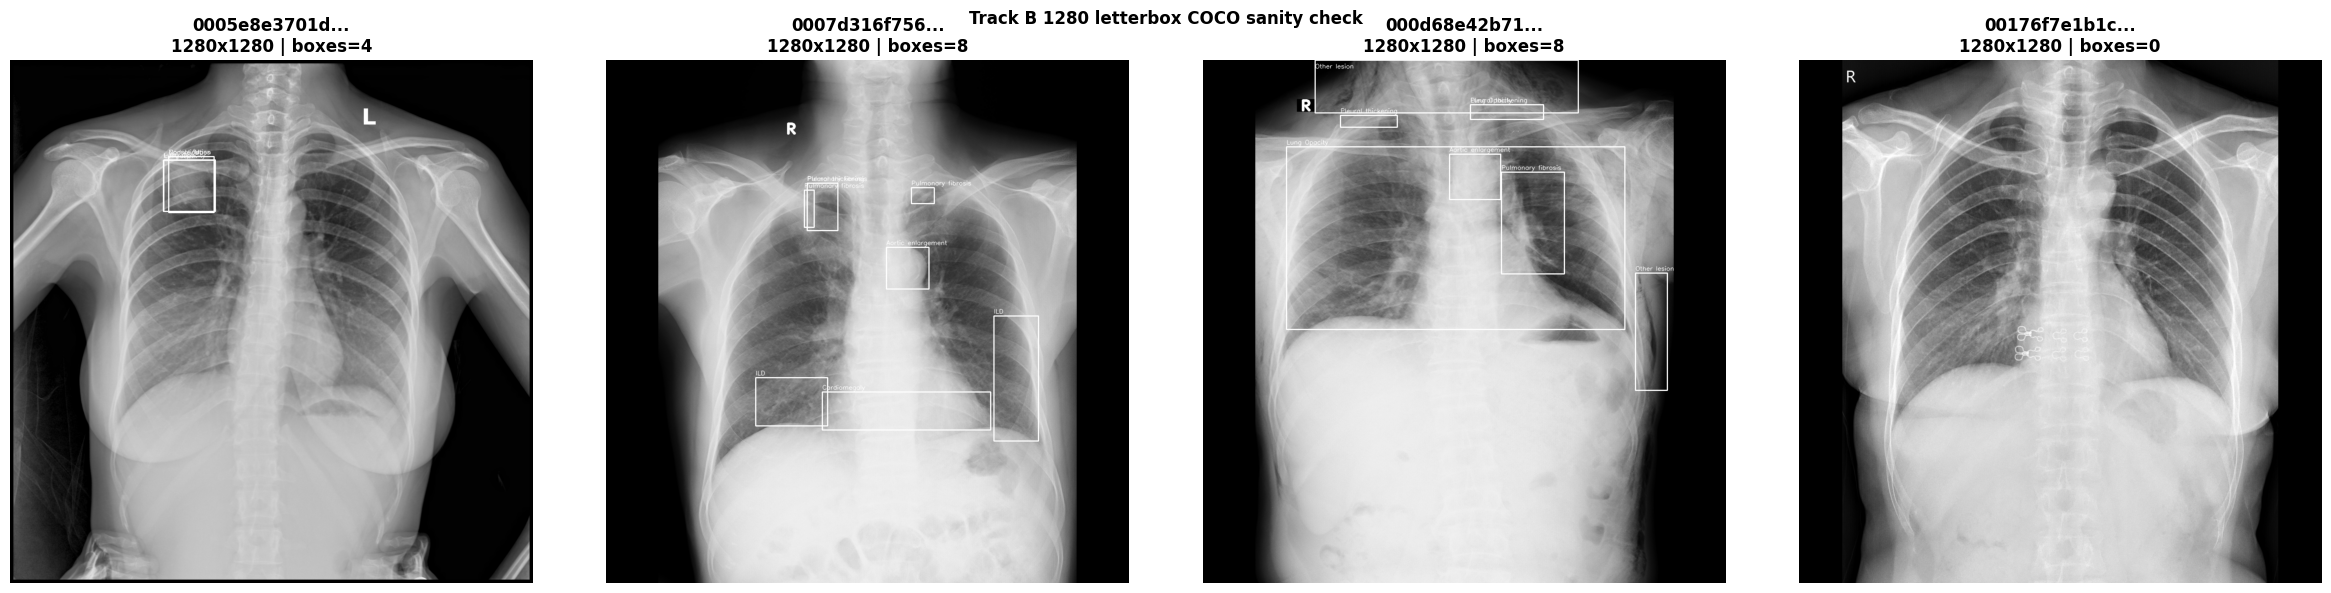


TRACK B CELL 3 SUMMARY
Target size       : 1280
Train PNG dir     : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/images_1280/train
Val PNG dir       : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/images_1280/val
Train PNG count   : 12,000
Val PNG count     : 3,000
Train COCO 1280   : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations/train_fold0_coco_1280.json
Val COCO 1280     : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/annotations/val_fold0_coco_1280.json
Metadata CSV      : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/data/dicom_to_png_letterbox_1280_meta.csv
Converted this run: 0
Errors            : 0

C

In [5]:
# ============================================================
# TRACK B - CELL 3 CLEAN COMPLETE
# 1280 image cache + COCO 1280 annotations
# Resume-safe:
#   - If PNG cache is complete, skip conversion entirely
#   - Only convert missing files
#   - Rebuild metadata + COCO 1280 quickly
#   - Show visual sanity check with bbox
# ============================================================

print("=" * 80)
print("TRACK B CELL 3 — 1280 IMAGE CACHE + COCO ANNOTATIONS")
print("=" * 80)

from pathlib import Path
import os
import json
import cv2
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from pydicom.pixel_data_handlers.util import apply_voi_lut

# ------------------------------------------------------------
# 1. Paths & config
# ------------------------------------------------------------

DATA_DIR = Path(
    "/workspace/Hokkaido_collaboration/km/lung_project/CRX/"
    "vinbigdata-chest-xray-abnormalities-detection"
).resolve()

os.chdir(DATA_DIR)

DICOM_TRAIN_DIR = DATA_DIR / "train"

TRACKB_DIR = DATA_DIR / "trackB_cxr_dino"
TRACKB_DATA_DIR = TRACKB_DIR / "data"
TRACKB_ANN_DIR = TRACKB_DATA_DIR / "annotations"

TARGET_SIZE = 1280
FOLD = 0

# COCO gốc từ Cell 2
ORIG_TRAIN_COCO_JSON = TRACKB_ANN_DIR / f"train_fold{FOLD}_coco.json"
ORIG_VAL_COCO_JSON = TRACKB_ANN_DIR / f"val_fold{FOLD}_coco.json"

# Output của Cell 3
IMG_DIR = TRACKB_DATA_DIR / f"images_{TARGET_SIZE}"
TRAIN_IMG_DIR = IMG_DIR / "train"
VAL_IMG_DIR = IMG_DIR / "val"

TRAIN_COCO_1280 = TRACKB_ANN_DIR / f"train_fold{FOLD}_coco_{TARGET_SIZE}.json"
VAL_COCO_1280 = TRACKB_ANN_DIR / f"val_fold{FOLD}_coco_{TARGET_SIZE}.json"

META_CSV = TRACKB_DATA_DIR / f"dicom_to_png_letterbox_{TARGET_SIZE}_meta.csv"

for p in [TRACKB_DATA_DIR, TRACKB_ANN_DIR, TRAIN_IMG_DIR, VAL_IMG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), DATA_DIR
assert DICOM_TRAIN_DIR.exists(), f"Missing DICOM dir: {DICOM_TRAIN_DIR}"
assert ORIG_TRAIN_COCO_JSON.exists(), f"Missing Cell 2 train COCO: {ORIG_TRAIN_COCO_JSON}"
assert ORIG_VAL_COCO_JSON.exists(), f"Missing Cell 2 val COCO: {ORIG_VAL_COCO_JSON}"

# False = không convert lại ảnh đã có.
FORCE_RECONVERT = False

# Chỉ dùng khi thiếu PNG.
NUM_WORKERS = min(24, os.cpu_count() or 8)
PNG_COMPRESSION = 0

# Cell này chỉ check shape vài ảnh mẫu để nhanh.
SAMPLE_SHAPE_CHECK_N = 5

print(f"DATA_DIR             : {DATA_DIR}")
print(f"DICOM_TRAIN_DIR      : {DICOM_TRAIN_DIR}")
print(f"TARGET_SIZE          : {TARGET_SIZE}")
print(f"TRAIN_IMG_DIR        : {TRAIN_IMG_DIR}")
print(f"VAL_IMG_DIR          : {VAL_IMG_DIR}")
print(f"ORIG_TRAIN_COCO_JSON : {ORIG_TRAIN_COCO_JSON}")
print(f"ORIG_VAL_COCO_JSON   : {ORIG_VAL_COCO_JSON}")
print(f"TRAIN_COCO_1280      : {TRAIN_COCO_1280}")
print(f"VAL_COCO_1280        : {VAL_COCO_1280}")
print(f"FORCE_RECONVERT      : {FORCE_RECONVERT}")

# ------------------------------------------------------------
# 2. Load original COCO split from Cell 2
# ------------------------------------------------------------

with open(ORIG_TRAIN_COCO_JSON, "r") as f:
    train_coco_orig = json.load(f)

with open(ORIG_VAL_COCO_JSON, "r") as f:
    val_coco_orig = json.load(f)

train_images = train_coco_orig["images"]
val_images = val_coco_orig["images"]

train_image_ids = [Path(x["file_name"]).stem for x in train_images]
val_image_ids = [Path(x["file_name"]).stem for x in val_images]

print("\nSplit from Cell 2:")
print(f"Train images: {len(train_image_ids):,}")
print(f"Val images  : {len(val_image_ids):,}")
print(f"Total       : {len(set(train_image_ids) | set(val_image_ids)):,}")

assert len(set(train_image_ids) & set(val_image_ids)) == 0, "Train/val overlap detected."

expected_train = len(train_image_ids)
expected_val = len(val_image_ids)

# ------------------------------------------------------------
# 3. Fast cache check by filename only
#    Không đọc toàn bộ 15,000 ảnh nên chạy rất nhanh.
# ------------------------------------------------------------

train_pngs = sorted(TRAIN_IMG_DIR.glob("*.png"))
val_pngs = sorted(VAL_IMG_DIR.glob("*.png"))

train_png_names = set(p.name for p in train_pngs)
val_png_names = set(p.name for p in val_pngs)

expected_train_names = set(f"{image_id}.png" for image_id in train_image_ids)
expected_val_names = set(f"{image_id}.png" for image_id in val_image_ids)

missing_train_names = sorted(expected_train_names - train_png_names)
missing_val_names = sorted(expected_val_names - val_png_names)

extra_train_names = sorted(train_png_names - expected_train_names)
extra_val_names = sorted(val_png_names - expected_val_names)

print("\nFast cache check:")
print(f"Train PNGs found : {len(train_pngs):,} / {expected_train:,}")
print(f"Val PNGs found   : {len(val_pngs):,} / {expected_val:,}")
print(f"Missing train    : {len(missing_train_names):,}")
print(f"Missing val      : {len(missing_val_names):,}")
print(f"Extra train      : {len(extra_train_names):,}")
print(f"Extra val        : {len(extra_val_names):,}")

need_convert = (
    FORCE_RECONVERT
    or len(missing_train_names) > 0
    or len(missing_val_names) > 0
)

# ------------------------------------------------------------
# 4. Helpers for conversion only if needed
# ------------------------------------------------------------

def normalize_to_uint8_safe(img):
    img = img.astype(np.float32)
    mn, mx = float(np.min(img)), float(np.max(img))

    if mx - mn < 1e-6:
        return np.zeros_like(img, dtype=np.uint8)

    img = (img - mn) / (mx - mn)
    return (img * 255.0).astype(np.uint8)


def letterbox_gray(img, target_size=1280, pad_value=0):
    h, w = img.shape[:2]

    scale = min(target_size / w, target_size / h)

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    canvas = np.full((target_size, target_size), pad_value, dtype=np.uint8)

    pad_x = (target_size - new_w) // 2
    pad_y = (target_size - new_h) // 2

    canvas[pad_y:pad_y + new_h, pad_x:pad_x + new_w] = resized

    meta = {
        "orig_width": int(w),
        "orig_height": int(h),
        "scale": float(scale),
        "resized_width": int(new_w),
        "resized_height": int(new_h),
        "pad_x": int(pad_x),
        "pad_y": int(pad_y),
        "target_size": int(target_size),
    }

    return canvas, meta


def convert_one_task(args):
    image_id, split_name, out_dir, dicom_dir, target_size, png_compression = args

    out_dir = Path(out_dir)
    dicom_dir = Path(dicom_dir)

    dicom_path = dicom_dir / f"{image_id}.dicom"
    out_path = out_dir / f"{image_id}.png"

    try:
        dcm = pydicom.dcmread(dicom_path)

        img = apply_voi_lut(dcm.pixel_array, dcm)

        if dcm.PhotometricInterpretation == "MONOCHROME1":
            img = np.max(img) - img

        img = normalize_to_uint8_safe(img)
        img_lb, meta = letterbox_gray(img, target_size=target_size, pad_value=0)

        ok = cv2.imwrite(
            str(out_path),
            img_lb,
            [cv2.IMWRITE_PNG_COMPRESSION, int(png_compression)]
        )

        if not ok:
            raise RuntimeError(f"cv2.imwrite failed: {out_path}")

        meta.update({
            "image_id": image_id,
            "split": split_name,
            "png_path": str(out_path),
            "photometric": getattr(dcm, "PhotometricInterpretation", "UNKNOWN"),
            "status": "converted",
            "error": "",
        })

        return meta

    except Exception as e:
        return {
            "image_id": image_id,
            "split": split_name,
            "png_path": str(out_path),
            "orig_width": np.nan,
            "orig_height": np.nan,
            "scale": np.nan,
            "resized_width": np.nan,
            "resized_height": np.nan,
            "pad_x": np.nan,
            "pad_y": np.nan,
            "target_size": target_size,
            "photometric": "",
            "status": "error",
            "error": str(e),
        }

# ------------------------------------------------------------
# 5. Convert missing files only
# ------------------------------------------------------------

convert_records = []

if need_convert:
    tasks = []

    if FORCE_RECONVERT:
        train_to_convert = train_image_ids
        val_to_convert = val_image_ids
    else:
        train_to_convert = [Path(x).stem for x in missing_train_names]
        val_to_convert = [Path(x).stem for x in missing_val_names]

    for image_id in train_to_convert:
        tasks.append((
            image_id,
            "train",
            str(TRAIN_IMG_DIR),
            str(DICOM_TRAIN_DIR),
            TARGET_SIZE,
            PNG_COMPRESSION,
        ))

    for image_id in val_to_convert:
        tasks.append((
            image_id,
            "val",
            str(VAL_IMG_DIR),
            str(DICOM_TRAIN_DIR),
            TARGET_SIZE,
            PNG_COMPRESSION,
        ))

    print(f"\nImages needing conversion: {len(tasks):,}")

    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as ex:
        futures = [ex.submit(convert_one_task, task) for task in tasks]

        for fut in tqdm(as_completed(futures), total=len(futures), desc="Convert missing PNGs"):
            convert_records.append(fut.result())

    convert_df = pd.DataFrame(convert_records)
    n_error = int((convert_df["status"] == "error").sum())

    if n_error > 0:
        display(convert_df[convert_df["status"] == "error"].head(20))
        raise RuntimeError("Some images failed to convert.")

    print("\nConversion summary:")
    print(convert_df["status"].value_counts(dropna=False))
else:
    print("\nNo conversion needed. Existing PNG cache is complete.")

# ------------------------------------------------------------
# 6. Build metadata from original COCO sizes
#    Fast: no DICOM read, no PNG read
# ------------------------------------------------------------

def compute_letterbox_meta_from_size(orig_width, orig_height, target_size=1280):
    w = int(orig_width)
    h = int(orig_height)

    scale = min(target_size / w, target_size / h)

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    pad_x = (target_size - new_w) // 2
    pad_y = (target_size - new_h) // 2

    return {
        "orig_width": w,
        "orig_height": h,
        "scale": float(scale),
        "resized_width": int(new_w),
        "resized_height": int(new_h),
        "pad_x": int(pad_x),
        "pad_y": int(pad_y),
        "target_size": int(target_size),
    }


meta_rows = []

for img in train_images:
    image_id = Path(img["file_name"]).stem
    meta = compute_letterbox_meta_from_size(img["width"], img["height"], TARGET_SIZE)
    meta.update({
        "image_id": image_id,
        "split": "train",
        "png_path": str(TRAIN_IMG_DIR / img["file_name"]),
        "status": "cached" if not FORCE_RECONVERT else "metadata",
        "error": "",
    })
    meta_rows.append(meta)

for img in val_images:
    image_id = Path(img["file_name"]).stem
    meta = compute_letterbox_meta_from_size(img["width"], img["height"], TARGET_SIZE)
    meta.update({
        "image_id": image_id,
        "split": "val",
        "png_path": str(VAL_IMG_DIR / img["file_name"]),
        "status": "cached" if not FORCE_RECONVERT else "metadata",
        "error": "",
    })
    meta_rows.append(meta)

meta_df = pd.DataFrame(meta_rows)
meta_df.to_csv(META_CSV, index=False)

print(f"\nSaved metadata CSV: {META_CSV}")

# ------------------------------------------------------------
# 7. Transform original COCO bboxes to 1280 letterbox coordinates
# ------------------------------------------------------------

meta_map = {
    row.image_id: {
        "scale": float(row.scale),
        "pad_x": int(row.pad_x),
        "pad_y": int(row.pad_y),
        "target_size": int(row.target_size),
    }
    for row in meta_df.itertuples(index=False)
}


def transform_bbox_xywh_to_letterbox(bbox, meta):
    x, y, w, h = bbox

    scale = meta["scale"]
    pad_x = meta["pad_x"]
    pad_y = meta["pad_y"]
    ts = meta["target_size"]

    x1 = x * scale + pad_x
    y1 = y * scale + pad_y
    x2 = (x + w) * scale + pad_x
    y2 = (y + h) * scale + pad_y

    x1 = float(np.clip(x1, 0, ts))
    y1 = float(np.clip(y1, 0, ts))
    x2 = float(np.clip(x2, 0, ts))
    y2 = float(np.clip(y2, 0, ts))

    new_w = x2 - x1
    new_h = y2 - y1

    if new_w <= 1 or new_h <= 1:
        return None

    return [x1, y1, new_w, new_h]


def make_letterbox_coco(coco_orig, split_name, out_json):
    new_coco = {
        "info": dict(coco_orig.get("info", {})),
        "licenses": coco_orig.get("licenses", []),
        "images": [],
        "annotations": [],
        "categories": coco_orig["categories"],
    }

    new_coco["info"]["description"] = (
        f"VinDr-CXR {TARGET_SIZE} letterbox annotations ({split_name})"
    )

    img_id_to_file = {}
    file_to_stem = {}

    for img in coco_orig["images"]:
        stem = Path(img["file_name"]).stem

        img_id_to_file[img["id"]] = img["file_name"]
        file_to_stem[img["file_name"]] = stem

        new_img = dict(img)
        new_img["width"] = TARGET_SIZE
        new_img["height"] = TARGET_SIZE
        new_img["file_name"] = img["file_name"]

        new_coco["images"].append(new_img)

    ann_id = 1

    for ann in coco_orig["annotations"]:
        file_name = img_id_to_file[ann["image_id"]]
        image_id_str = file_to_stem[file_name]

        meta = meta_map[image_id_str]
        new_bbox = transform_bbox_xywh_to_letterbox(ann["bbox"], meta)

        if new_bbox is None:
            continue

        new_ann = dict(ann)
        new_ann["id"] = ann_id
        new_ann["bbox"] = [float(v) for v in new_bbox]
        new_ann["area"] = float(new_bbox[2] * new_bbox[3])

        new_coco["annotations"].append(new_ann)
        ann_id += 1

    with open(out_json, "w") as f:
        json.dump(new_coco, f)

    return new_coco


train_coco_1280 = make_letterbox_coco(train_coco_orig, "train", TRAIN_COCO_1280)
val_coco_1280 = make_letterbox_coco(val_coco_orig, "val", VAL_COCO_1280)

print("\nSaved 1280 COCO annotations:")
print(f"Train: {TRAIN_COCO_1280}")
print(f"Val  : {VAL_COCO_1280}")

# ------------------------------------------------------------
# 8. Count checks
# ------------------------------------------------------------

train_pngs = sorted(TRAIN_IMG_DIR.glob("*.png"))
val_pngs = sorted(VAL_IMG_DIR.glob("*.png"))

print("\nPNG counts:")
print(f"Train PNGs: {len(train_pngs):,}")
print(f"Val PNGs  : {len(val_pngs):,}")

assert len(train_pngs) == expected_train, "Train PNG count mismatch."
assert len(val_pngs) == expected_val, "Val PNG count mismatch."

assert len(train_coco_1280["images"]) == expected_train
assert len(val_coco_1280["images"]) == expected_val
assert len(train_coco_1280["categories"]) == 14
assert len(val_coco_1280["categories"]) == 14

print("\nCOCO counts:")
print(f"Train images      : {len(train_coco_1280['images']):,}")
print(f"Train annotations : {len(train_coco_1280['annotations']):,}")
print(f"Val images        : {len(val_coco_1280['images']):,}")
print(f"Val annotations   : {len(val_coco_1280['annotations']):,}")

# ------------------------------------------------------------
# 9. Visual sanity check
# ------------------------------------------------------------

def draw_coco_boxes(img_gray, image_info, coco, max_boxes=8):
    """
    Draw COCO-format boxes on one grayscale image.
    COCO bbox format: [x, y, width, height]
    """
    img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

    anns = [
        ann for ann in coco["annotations"]
        if ann["image_id"] == image_info["id"]
    ]

    anns = anns[:max_boxes]

    cat_map = {
        int(cat["id"]): cat["name"]
        for cat in coco["categories"]
    }

    for ann in anns:
        x, y, w, h = ann["bbox"]

        x1 = int(round(x))
        y1 = int(round(y))
        x2 = int(round(x + w))
        y2 = int(round(y + h))

        name = cat_map.get(int(ann["category_id"]), str(ann["category_id"]))

        cv2.rectangle(
            img_rgb,
            (x1, y1),
            (x2, y2),
            (255, 255, 255),
            2
        )

        cv2.putText(
            img_rgb,
            name[:18],
            (x1, max(20, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    return img_rgb, len(anns)


# Pick 3 abnormal validation images + 1 normal validation image
val_ann_image_ids = set(
    ann["image_id"]
    for ann in val_coco_1280["annotations"]
)

abnormal_infos = [
    img for img in val_coco_1280["images"]
    if img["id"] in val_ann_image_ids
][:3]

normal_infos = [
    img for img in val_coco_1280["images"]
    if img["id"] not in val_ann_image_ids
][:1]

sample_infos = abnormal_infos + normal_infos

print("\nVisual sanity check:")
print(f"Abnormal samples: {len(abnormal_infos)}")
print(f"Normal samples  : {len(normal_infos)}")

if len(sample_infos) > 0:
    fig, axes = plt.subplots(
        1,
        len(sample_infos),
        figsize=(6 * len(sample_infos), 6)
    )

    if len(sample_infos) == 1:
        axes = [axes]

    for ax, info in zip(axes, sample_infos):
        img_path = VAL_IMG_DIR / info["file_name"]

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        assert img is not None, f"Cannot read image: {img_path}"
        assert img.shape == (TARGET_SIZE, TARGET_SIZE), f"Bad shape {img.shape}: {img_path}"

        img_draw, n_boxes = draw_coco_boxes(
            img_gray=img,
            image_info=info,
            coco=val_coco_1280,
            max_boxes=8
        )

        ax.imshow(img_draw)
        ax.set_title(
            f"{Path(info['file_name']).stem[:12]}...\n"
            f"{TARGET_SIZE}x{TARGET_SIZE} | boxes={n_boxes}",
            fontweight="bold"
        )
        ax.axis("off")

    plt.suptitle(
        "Track B 1280 letterbox COCO sanity check",
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()
else:
    print("No sample images available for visualization.")

# ------------------------------------------------------------
# 10. Summary
# ------------------------------------------------------------

converted_this_run = len(convert_records)
num_error = 0

print("\n" + "=" * 80)
print("TRACK B CELL 3 SUMMARY")
print("=" * 80)
print(f"Target size       : {TARGET_SIZE}")
print(f"Train PNG dir     : {TRAIN_IMG_DIR}")
print(f"Val PNG dir       : {VAL_IMG_DIR}")
print(f"Train PNG count   : {len(train_pngs):,}")
print(f"Val PNG count     : {len(val_pngs):,}")
print(f"Train COCO 1280   : {TRAIN_COCO_1280}")
print(f"Val COCO 1280     : {VAL_COCO_1280}")
print(f"Metadata CSV      : {META_CSV}")
print(f"Converted this run: {converted_this_run:,}")
print(f"Errors            : {num_error}")

print("\nCell tiếp theo:")
print("TRACK B CELL 4 — build image-level labels for deep learning classifier branch.")

In [10]:
# ============================================================
# TRACK B - CELL 4: DETECTOR READINESS CHECK (COMPACT VERSION)
# ============================================================
import os, json, subprocess, shutil
from pathlib import Path

print("=" * 60 + "\nTRACK B CELL 4 — DETECTOR READINESS CHECK\n" + "=" * 60)

# 1. Paths Setup
TRACKB_DIR = Path("/workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino").resolve()
DATA_DIR = TRACKB_DIR / "data"
MMDET_SRC = TRACKB_DIR / "mmdetection_py310"
os.chdir(TRACKB_DIR.parent)

# 2. Check Data & Annotations (12000 train, 3000 val)
for split, expected_count in [("train", 12000), ("val", 3000)]:
    img_dir = DATA_DIR / f"images_1280/{split}"
    coco_json = DATA_DIR / f"annotations/{split}_fold0_coco_1280.json"
    
    assert img_dir.exists() and coco_json.exists(), f"❌ Missing {split} data or json!"
    assert len(list(img_dir.glob("*.png"))) == expected_count, f"❌ Wrong {split} PNG count"
    with open(coco_json) as f:
        assert len(json.load(f)["images"]) == expected_count, f"❌ Wrong {split} COCO count"
print("✅ Detector data is ready (Images & COCO validated).")

# 3. Check Conda Environment & MMDetection dependencies
ENV_NAME = "cxr_mmdet310"
conda_paths = [shutil.which("conda")] + [f"{p}/conda" for p in ["/workspace/miniconda3/bin", "/root/miniconda3/bin", "/opt/conda/bin"]]
CONDA_EXE = next((p for p in conda_paths if p and Path(p).exists()), None)
assert CONDA_EXE, "❌ Không tìm thấy file thực thi conda!"

chk_code = "import torch, mmdet, mmcv; print(f'PyTorch {torch.__version__} | GPU: {torch.cuda.is_available()} | mmdet {mmdet.__version__}')"
res = subprocess.run([str(CONDA_EXE), "run", "-n", ENV_NAME, "python", "-c", chk_code], capture_output=True, text=True)
assert res.returncode == 0, f"❌ Conda env {ENV_NAME} error:\n{res.stderr}"
print(f"✅ Conda env '{ENV_NAME}' is ready: {res.stdout.strip()}")

# 4. Check MMDetection Source
assert (MMDET_SRC / "tools/train.py").exists(), f"❌ MMDetection source missing at {MMDET_SRC}. Please git clone it."
print("✅ MMDetection source is ready.")

# 5. Summary & Next Steps
print("\n" + "=" * 60)
print("🚀 ALL CHECKS PASSED. NEXT STEPS (RUN IN TERMINAL):")
print("=" * 60)
print(f"""
1. cd {TRACKB_DIR.parent}
2. conda activate {ENV_NAME}
3. Create and run external scripts in: {TRACKB_DIR}/detector_scripts
   - 01_make_dino_config.py
   - 02_run_debug_detector.py
   - ...
""")

TRACK B CELL 4 — DETECTOR READINESS CHECK
✅ Detector data is ready (Images & COCO validated).
✅ Conda env 'cxr_mmdet310' is ready: PyTorch 2.1.0+cu121 | GPU: True | mmdet 3.3.0
✅ MMDetection source is ready.

🚀 ALL CHECKS PASSED. NEXT STEPS (RUN IN TERMINAL):

1. cd /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection
2. conda activate cxr_mmdet310
3. Create and run external scripts in: /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/detector_scripts
   - 01_make_dino_config.py
   - 02_run_debug_detector.py
   - ...



TRACK B DETECTOR TRAINING SUMMARY
Log file        : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/detector_logs/fast_train_raw.log
Train rows      : 135
Val rows        : 5
Saved train CSV : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/training_plots/detector_train_log_parsed.csv
Saved val CSV   : /workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/training_plots/detector_val_log_parsed.csv


,epoch,iter,total_iter,global_iter,lr,loss,loss_cls,loss_bbox,loss_iou
130,5,2300,2758,13332,5.000000e-07,12.7941,0.3599,0.1699,0.4429
131,5,2400,2758,13432,5.000000e-07,12.9387,0.3439,0.1753,0.4608
132,5,2500,2758,13532,5.000000e-07,11.4427,0.3089,0.1452,0.4343
133,5,2600,2758,13632,5.000000e-07,12.1404,0.3283,0.1517,0.4379
134,5,2700,2758,13732,5.000000e-07,12.4240,0.3208,0.1654,0.4403


,epoch,bbox_mAP,bbox_mAP_s,bbox_mAP_m,bbox_mAP_l
0,1,0.106,0.015,0.087,0.113
1,2,0.165,0.157,0.106,0.178
2,3,0.210,0.119,0.144,0.228
3,4,0.243,0.190,0.177,0.258
4,5,0.247,0.251,0.179,0.261


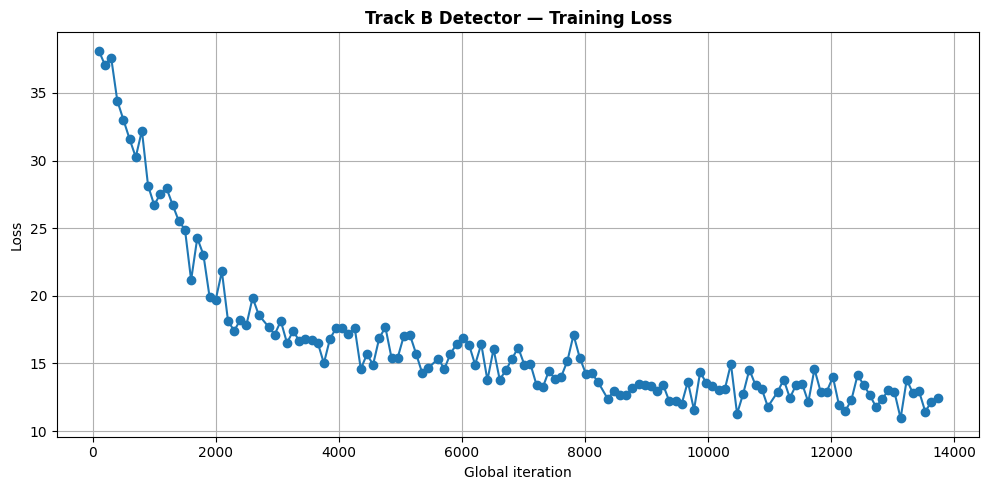

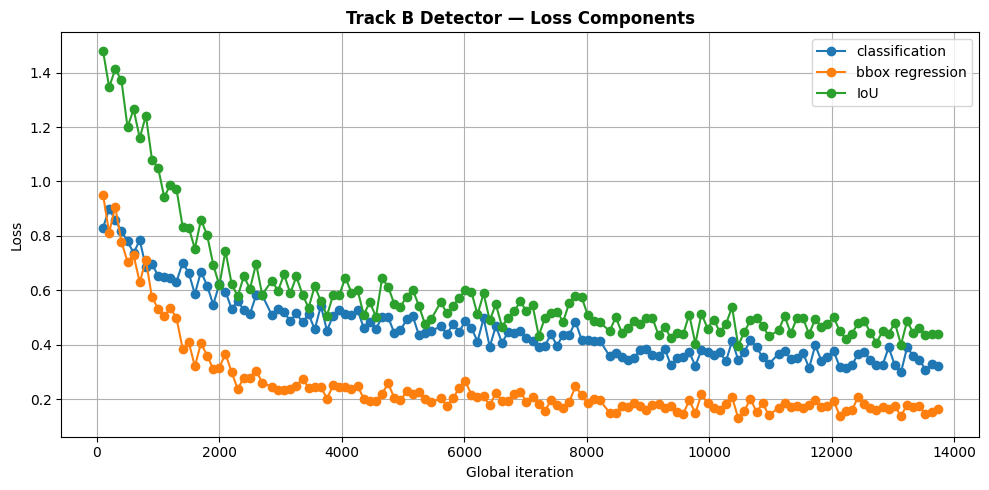

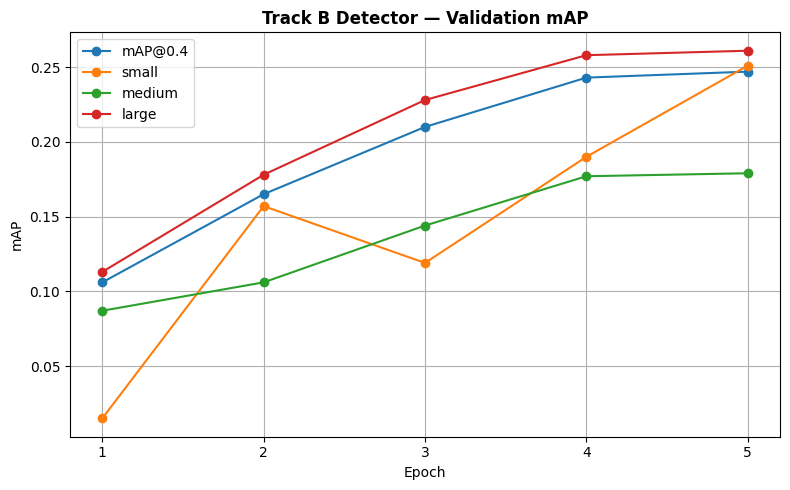


Saved plots:
/workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/training_plots/detector_train_loss.png
/workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/training_plots/detector_loss_components.png
/workspace/Hokkaido_collaboration/km/lung_project/CRX/vinbigdata-chest-xray-abnormalities-detection/trackB_cxr_dino/training_plots/detector_val_map.png


In [11]:
# ============================================================
# TRACK B — DETECTOR TRAINING CURVES
# Parse MMDetection raw log and plot loss / validation mAP
# ============================================================

from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path(
    "/workspace/Hokkaido_collaboration/km/lung_project/CRX/"
    "vinbigdata-chest-xray-abnormalities-detection"
)

LOG_PATH = DATA_DIR / "trackB_cxr_dino/detector_logs/fast_train_raw.log"
OUT_DIR = DATA_DIR / "trackB_cxr_dino/training_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert LOG_PATH.exists(), f"Missing log file: {LOG_PATH}"

train_rows = []
val_rows = []

train_pat = re.compile(
    r"Epoch\(train\) \[(\d+)\]\[\s*(\d+)/(\d+)\].*?"
    r"lr: ([\deE\+\-\.]+).*?"
    r"loss: ([\d\.]+).*?"
    r"loss_cls: ([\d\.]+).*?"
    r"loss_bbox: ([\d\.]+).*?"
    r"loss_iou: ([\d\.]+)"
)

val_pat = re.compile(
    r"Epoch\(val\) \[(\d+)\]\[\d+/\d+\].*?"
    r"coco/bbox_mAP: ([\-\d\.]+).*?"
    r"coco/bbox_mAP_s: ([\-\d\.]+).*?"
    r"coco/bbox_mAP_m: ([\-\d\.]+).*?"
    r"coco/bbox_mAP_l: ([\-\d\.]+)"
)

with open(LOG_PATH, "r", errors="ignore") as f:
    for line in f:
        m = train_pat.search(line)
        if m:
            epoch, it, total, lr, loss, loss_cls, loss_bbox, loss_iou = m.groups()
            train_rows.append({
                "epoch": int(epoch),
                "iter": int(it),
                "total_iter": int(total),
                "global_iter": (int(epoch) - 1) * int(total) + int(it),
                "lr": float(lr),
                "loss": float(loss),
                "loss_cls": float(loss_cls),
                "loss_bbox": float(loss_bbox),
                "loss_iou": float(loss_iou),
            })

        m = val_pat.search(line)
        if m:
            epoch, map_all, map_s, map_m, map_l = m.groups()
            val_rows.append({
                "epoch": int(epoch),
                "bbox_mAP": float(map_all),
                "bbox_mAP_s": float(map_s),
                "bbox_mAP_m": float(map_m),
                "bbox_mAP_l": float(map_l),
            })

train_df = pd.DataFrame(train_rows)
val_df = pd.DataFrame(val_rows)

train_csv = OUT_DIR / "detector_train_log_parsed.csv"
val_csv = OUT_DIR / "detector_val_log_parsed.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)

print("=" * 80)
print("TRACK B DETECTOR TRAINING SUMMARY")
print("=" * 80)
print(f"Log file        : {LOG_PATH}")
print(f"Train rows      : {len(train_df):,}")
print(f"Val rows        : {len(val_df):,}")
print(f"Saved train CSV : {train_csv}")
print(f"Saved val CSV   : {val_csv}")

display(train_df.tail())
display(val_df)

# ------------------------------------------------------------
# Plot 1: total loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(train_df["global_iter"], train_df["loss"], marker="o")
plt.title("Track B Detector — Training Loss", fontweight="bold")
plt.xlabel("Global iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()

loss_plot = OUT_DIR / "detector_train_loss.png"
plt.savefig(loss_plot, dpi=200)
plt.show()

# ------------------------------------------------------------
# Plot 2: loss components
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(train_df["global_iter"], train_df["loss_cls"], marker="o", label="classification")
plt.plot(train_df["global_iter"], train_df["loss_bbox"], marker="o", label="bbox regression")
plt.plot(train_df["global_iter"], train_df["loss_iou"], marker="o", label="IoU")
plt.title("Track B Detector — Loss Components", fontweight="bold")
plt.xlabel("Global iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

component_plot = OUT_DIR / "detector_loss_components.png"
plt.savefig(component_plot, dpi=200)
plt.show()

# ------------------------------------------------------------
# Plot 3: validation mAP
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(val_df["epoch"], val_df["bbox_mAP"], marker="o", label="mAP@0.4")
plt.plot(val_df["epoch"], val_df["bbox_mAP_s"], marker="o", label="small")
plt.plot(val_df["epoch"], val_df["bbox_mAP_m"], marker="o", label="medium")
plt.plot(val_df["epoch"], val_df["bbox_mAP_l"], marker="o", label="large")
plt.title("Track B Detector — Validation mAP", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.xticks(val_df["epoch"])
plt.legend()
plt.grid(True)
plt.tight_layout()

map_plot = OUT_DIR / "detector_val_map.png"
plt.savefig(map_plot, dpi=200)
plt.show()

print("\nSaved plots:")
print(loss_plot)
print(component_plot)
print(map_plot)